# Chapter 3 — Causal Machine Learning  
## Heterogeneous Effects, Meta-Learners, and Double Machine Learning

**Course:** Causal Intelligence  
**Instructor:** Prof. Reza Arghandeh, Western Norway University of Applied Sciences, Norway  

---

## Main purpose

This chapter introduces **causal machine learning** as a practical framework for estimating causal effects when relationships are nonlinear, high-dimensional, and heterogeneous across individuals or units.

Chapters 1 and 2 introduced association, intervention, counterfactual reasoning, causal graphs, and causal discovery. This chapter moves from causal reasoning and graph-based design to **effect estimation with machine learning**.

The central message is:

> Machine learning can improve causal effect estimation, but only when it is guided by a causal design that clearly defines the treatment, outcome, estimand, adjustment strategy, and assumptions.

We use one simulated healthcare example throughout the chapter. The setting is a hospital evaluating whether a treatment improves patient recovery. The dataset includes confounding, a continuous recovery score, and known heterogeneous treatment effects. This allows us to compare naive estimates, adjusted outcome models, meta-learners, and Double Machine Learning in a controlled setting.

The goal is not only to ask whether treatment works on average, but also to understand which patients are expected to benefit more or less.


## Chapter structure

1. Why causal machine learning?
2. Running example: treatment, severity, and recovery score
3. The fundamental problem of causal inference
4. Potential outcomes and treatment-effect estimands
5. Why ordinary machine learning is not enough
6. Baseline estimators: naive comparison and adjusted outcome modeling
7. Meta-learners: S-learner, T-learner, and X-learner
8. Heterogeneous treatment effects and CATE visualization
9. Double Machine Learning: orthogonalization and sample splitting
10. Practical guidance for causal ML projects
11. Chapter summary
12. References and further reading


# </br>

---
## 1. Why Causal Machine Learning?

Ordinary machine learning is mainly designed for **prediction**.

Given features $X$, a predictive model learns a function such as:

$$\hat{f}(X) \approx E[Y \mid X]$$

This answers a question like:

> *What outcome do we expect for a patient with these characteristics?*

For example, a model may predict a patient’s recovery score from age, severity, biomarkers, and treatment status. This can be useful when the goal is forecasting.

However, many scientific and decision-making problems are not only about prediction. They are about **actions**.

We often want to ask:

> *What would happen if we changed something?*

For example:

- What if we gave the treatment to all patients?
- Which patients would benefit most from treatment?

A causal question has the form:

$$E[Y \mid do(T = 1)] - E[Y \mid do(T = 0)]$$

Here, $T$ is a treatment, intervention, policy, or action.

This expression asks:

> *How would the outcome change if we actively assigned treatment instead of no treatment?*

This is different from the ordinary observational comparison:

$$E[Y \mid T = 1] - E[Y \mid T = 0]$$

The observational comparison only compares patients who happened to receive treatment with patients who happened not to receive treatment.

If treatment was not randomly assigned, these two groups may already be different before treatment. For example, sicker patients may be more likely to receive treatment. This is the main reason causal machine learning is needed.

Causal machine learning combines two ideas:

| Component | Role |
|---|---|
| **Causal inference** | Defines the causal question, treatment, outcome, estimand, adjustment strategy, and assumptions |
| **Machine learning** | Helps estimate complex outcome models, treatment assignment models, and heterogeneous treatment effects |



In this chapter, machine learning is useful for three tasks:

1. estimating outcome models, such as:

$$E[Y \mid T, X]$$

2. estimating treatment assignment models, such as:

$$P(T = 1 \mid X)$$

3. estimating how treatment effects vary across patients or subgroups:

$$E[Y(1) - Y(0) \mid X=x]$$

The third task is especially important. A treatment may help on average, but not equally for everyone. Some patients may benefit more, while others may benefit less.

Therefore, this chapter focuses on **causal effect estimation**, with special attention to **heterogeneous treatment effects**.

We first introduce potential outcomes and treatment-effect estimands. Then we study meta-learners and finally introduce the intuition behind Double Machine Learning.

## Notebook setup: libraries and visual style

The core demonstrations use standard Python libraries so that the notebook can run in Google Colab without heavy installation requirements. Optional EconML code is included later. If EconML is not installed, the notebook will still run and will show installation instructions.


In [33]:
# Basic imports used throughout the chapter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)

# Harmonized visual style for the chapter
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.family": "DejaVu Sans",
})

COLORS = {
    "navy": "#1f4e79",
    "orange": "#f28e2b",
    "green": "#59a14f",
    "red": "#e15759",
    "gray": "#7f7f7f",
    "light_blue": "#d8e8f5",
    "light_orange": "#fde6c8",
    "light_green": "#d9ead3",
    "light_red": "#f4cccc",
}

def clean_axis(ax):
    """Apply a consistent, minimal style to matplotlib axes."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.25)
    return ax

def sigmoid(x):
    """Numerically stable sigmoid function for simple simulations."""
    return 1 / (1 + np.exp(-x))

def draw_dag(
    edges,
    pos=None,
    title="Causal graph",
    node_colors=None,
    figsize=(8, 5),
    node_size=2600,
    connectionstyle="arc3,rad=0.08",
):
    """Draw a directed causal graph with a consistent teaching style."""
    G = nx.DiGraph()
    G.add_edges_from(edges)

    if pos is None:
        pos = nx.spring_layout(G, seed=42)

    node_colors = node_colors or {
        node: COLORS["light_blue"] for node in G.nodes()
    }

    colors = [
        node_colors.get(node, COLORS["light_blue"])
        for node in G.nodes()
    ]

    fig, ax = plt.subplots(figsize=figsize)

    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=colors,
        node_size=node_size,
        edgecolors=COLORS["navy"],
        linewidths=1.2,
        ax=ax,
    )

    nx.draw_networkx_labels(
        G,
        pos,
        font_size=9,
        font_weight="bold",
        ax=ax,
    )

    nx.draw_networkx_edges(
        G,
        pos,
        arrows=True,
        arrowsize=18,
        width=1.6,
        edge_color="black",
        connectionstyle=connectionstyle,
        min_source_margin=18,
        min_target_margin=18,
        ax=ax,
    )

    ax.set_title(title, fontsize=13)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    return G

</br>

---
## 2. Running Example: Treatment, Severity, and Recovery Score

We continue with the same healthcare setting from Chapter 2.

The story is simple:

> A hospital wants to know whether a treatment improves patient recovery.

However, treatment is **not randomly assigned**.

More severe patients are more likely to receive treatment. Patients with worse biomarker values are also more likely to receive treatment. This creates **confounding**.

For Chapter 3, we use an adapted simulated dataset. It keeps the same causal logic from Chapter 2, but adds two useful elements for causal machine learning:

1. a continuous outcome: `RecoveryScore`,
2. simulated potential outcomes: `Y0` and `Y1`.

This helps us teach and evaluate treatment-effect estimators.

Compared with Chapter 2:

- Chapter 2 focused on **graphs, adjustment, and causal discovery**.
- Chapter 3 focuses on **effect estimation with machine learning**.
- The main outcome is now `RecoveryScore`, not only binary `Recovery`.

The binary `Recovery` variable is kept only as an auxiliary outcome.

---

### Variables

| Variable | Meaning | Role in this chapter |
|---|---|---|
| `Age` | Patient age | Pre-treatment covariate |
| `Socioeconomic` | Socioeconomic status proxy | Pre-treatment covariate |
| `Severity` | Baseline disease severity | Confounder and effect modifier |
| `Biomarker` | Clinical biomarker before treatment | Confounder and effect modifier |
| `Treatment` | Whether the patient receives treatment | Treatment/intervention |
| `Inflammation` | Post-treatment biological response | Mediator; not used for total-effect adjustment |
| `RecoveryScore` | Continuous recovery score | Main outcome |
| `Recovery` | Binary recovery indicator | Auxiliary outcome |
| `TrueTreatmentEffect` | Known simulated treatment effect | Used only for teaching and evaluation |

---

### Main causal question

The first question is about the **average treatment effect**:

$$E[RecoveryScore \mid do(Treatment=1)] - E[RecoveryScore \mid do(Treatment=0)]$$

This asks:

> *What would be the average difference in recovery if all patients were treated compared with if no patients were treated?*

This is a population-level question.

It gives one average effect for the whole patient population.

---

### Heterogeneity question

The second question is about **who benefits more or less**:

$$E[RecoveryScore(1) - RecoveryScore(0) \mid X=x]$$

Here, $X$ contains pre-treatment patient characteristics, such as:

- `Age`
- `Severity`
- `Socioeconomic`
- `Biomarker`

This asks:

> *Does the treatment effect vary across different patient profiles?*

For example:

- Do high-severity patients benefit more than low-severity patients?
- Does the expected treatment benefit change with age?
- Do biomarker values modify the treatment effect?

This quantity is called the **Conditional Average Treatment Effect**, or **CATE**.

The difference is:

| Question | Estimand | Meaning |
|---|---|---|
| Does treatment work on average? | ATE | One average effect for the population |
| For whom does treatment work more or less? | CATE | Effect varies by patient characteristics |

This distinction matters for decision-making. A treatment may be beneficial on average, but the expected benefit may be larger for some patients and smaller for others.

---

### Why simulation is useful here

The next code cell simulates the dataset.

Because this is a simulation, we generate both potential outcomes for each patient:

- `Y0`: recovery score under no treatment,
- `Y1`: recovery score under treatment.

In real observational data, we would observe only one of these outcomes for each patient.

Here, we keep both only for teaching and evaluation. This allows us to compare causal ML estimates with the known simulated treatment effect.

In [34]:
def simulate_healthcare_causal_ml_data(n=3000, seed=42):
    """Simulate a healthcare dataset for causal ML teaching.

    The data include confounding and heterogeneous treatment effects.
    Treatment is assigned observationally, not randomly.
    The true potential outcomes are known because this is a simulation.
    """
    rng = np.random.default_rng(seed)

    # Background variables
    age = rng.normal(55, 12, n)
    age_std = (age - 55) / 12
    socioeconomic = rng.normal(0, 1, n)

    # Pre-treatment health variables
    severity = 0.45 * age_std - 0.55 * socioeconomic + rng.normal(0, 1, n)
    biomarker = 0.85 * severity + 0.20 * age_std + rng.normal(0, 0.8, n)

    # Observational treatment assignment:
    # sicker patients and patients with worse biomarkers are more likely to receive treatment.
    p_treat = sigmoid(-0.30 + 0.95 * severity + 0.45 * biomarker - 0.15 * socioeconomic)
    treatment = rng.binomial(1, p_treat, n)

    # Heterogeneous treatment effect:
    # treatment helps most for higher-severity patients, but less for older patients.
    true_tau = (
        4.5
        + 3.0 * sigmoid(severity)
        + 1.2 * (biomarker > np.median(biomarker)).astype(float)
        - 0.8 * age_std
    )
    true_tau = np.clip(true_tau, 1.0, 10.0)

    # Potential outcomes for a continuous recovery score.
    # Higher recovery score is better.
    baseline_noise = rng.normal(0, 4.0, n)
    y0 = 72 - 7.5 * severity + 2.0 * socioeconomic - 1.2 * age_std + baseline_noise
    y1 = y0 + true_tau

    # Observed outcome under the treatment actually received.
    recovery_score = np.where(treatment == 1, y1, y0)

    # Mediator generated after treatment; included to connect with Chapter 2,
    # but not used for total-effect adjustment.
    inflammation = 1.10 * severity - 0.75 * treatment + rng.normal(0, 0.9, n)

    # Binary recovery indicator as an auxiliary outcome.
    p_recovery = sigmoid((recovery_score - 70) / 8)
    recovery = rng.binomial(1, p_recovery, n)

    return pd.DataFrame({
        "Age": age,
        "Socioeconomic": socioeconomic,
        "Severity": severity,
        "Biomarker": biomarker,
        "Treatment": treatment,
        "Inflammation": inflammation,
        "RecoveryScore": recovery_score,
        "Recovery": recovery,
        "Propensity": p_treat,
        "Y0": y0,
        "Y1": y1,
        "TrueTreatmentEffect": true_tau,
    })

health = simulate_healthcare_causal_ml_data()
health.head()


,Age,Socioeconomic,Severity,Biomarker,Treatment,Inflammation,RecoveryScore,Recovery,Propensity,Y0,Y1,TrueTreatmentEffect
0,58.656605,1.249023,-0.324723,-0.132452,0,0.301883,73.402845,1,0.298292,73.402845,78.917646,5.514802
1,42.520191,0.687692,-0.899567,-1.867151,0,-1.567240,85.229287,1,0.109295,85.229287,91.428693,6.199406
2,64.005414,1.966127,0.120377,0.333036,0,-0.083613,78.178072,1,0.418071,78.178072,84.867885,6.689813
3,66.286777,-1.547833,1.881295,0.870464,1,1.279177,62.542332,0,0.891979,54.991504,62.542332,7.550828
4,31.587578,-0.265360,-3.717840,-2.600875,0,-2.610224,99.244738,1,0.006947,99.244738,105.376698,6.131960


</br>

---
The next code cell summarizes the dataset by treatment group.

The goal is to check whether treated and untreated patients look comparable before treatment.

Pay attention to three columns:

- `mean_severity`: Are treated patients more severe?
- `mean_biomarker`: Do treated patients have worse biomarker values?
- `mean_recovery_score`: Do the two groups have different observed outcomes?

If treated patients are more severe or have worse biomarkers, then a simple comparison of recovery scores may be confounded.

The column `mean_true_effect` is included only because this is a simulation. In real data, we would not know the true treatment effect for each patient.

In [35]:
summary = health.groupby("Treatment").agg(
    patients=("RecoveryScore", "size"),
    mean_severity=("Severity", "mean"),
    mean_biomarker=("Biomarker", "mean"),
    mean_recovery_score=("RecoveryScore", "mean"),
    recovery_rate=("Recovery", "mean"),
    mean_true_effect=("TrueTreatmentEffect", "mean"),
)
summary.round(3)


,patients,mean_severity,mean_biomarker,mean_recovery_score,recovery_rate,mean_true_effect
Treatment,,,,,,
0,1667,-0.644,-0.705,77.732,0.696,6.152
1,1333,0.760,0.785,72.733,0.563,7.177


</br>

---
The next code cell visualizes the main differences between treated and untreated patients.

We look at three things:

1. baseline severity,
2. observed recovery score,
3. average recovery score by treatment group.

The goal is to see whether the two groups are comparable.

If treated patients are more severe at baseline, then their recovery scores may reflect two things at the same time:

- the possible effect of treatment,
- their worse initial health condition.

So the raw difference in recovery scores should not be read as a causal effect.

The plots help us see the main problem:

> Treated and untreated patients are not the same before treatment.

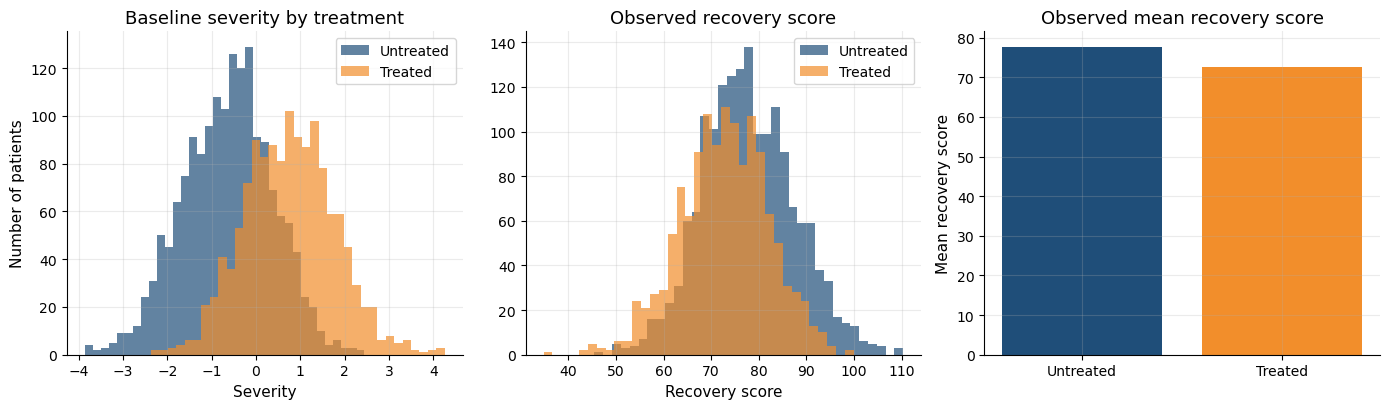

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

axes[0].hist(
    health.loc[health["Treatment"] == 0, "Severity"],
    bins=35, alpha=0.70, label="Untreated", color=COLORS["navy"]
)
axes[0].hist(
    health.loc[health["Treatment"] == 1, "Severity"],
    bins=35, alpha=0.70, label="Treated", color=COLORS["orange"]
)
axes[0].set_title("Baseline severity by treatment")
axes[0].set_xlabel("Severity")
axes[0].set_ylabel("Number of patients")
axes[0].legend()
clean_axis(axes[0])

axes[1].hist(
    health.loc[health["Treatment"] == 0, "RecoveryScore"],
    bins=35, alpha=0.70, label="Untreated", color=COLORS["navy"]
)
axes[1].hist(
    health.loc[health["Treatment"] == 1, "RecoveryScore"],
    bins=35, alpha=0.70, label="Treated", color=COLORS["orange"]
)
axes[1].set_title("Observed recovery score")
axes[1].set_xlabel("Recovery score")
axes[1].legend()
clean_axis(axes[1])

rates = health.groupby("Treatment")["RecoveryScore"].mean()
axes[2].bar(["Untreated", "Treated"], rates.values, color=[COLORS["navy"], COLORS["orange"]])
axes[2].set_title("Observed mean recovery score")
axes[2].set_ylabel("Mean recovery score")
clean_axis(axes[2])

plt.tight_layout()
plt.show()


### Interpretation

The plots show the core problem in this dataset.

- Treated patients have higher baseline severity.
- Treated patients also have lower observed recovery scores.
- A naive comparison would therefore suggest that treatment is harmful.

But this conclusion would be misleading.

The treated group started from a worse health condition. So the raw difference mixes two things:

1. the possible effect of treatment,
2. pre-treatment differences between the two groups.

The raw comparison estimates an association:

$$E[RecoveryScore \mid Treatment=1] - E[RecoveryScore \mid Treatment=0]$$

But the causal question is different:

$$E[RecoveryScore \mid do(Treatment=1)] - E[RecoveryScore \mid do(Treatment=0)]$$

These two quantities are not the same when treatment assignment is confounded.

The key lesson is:

> Before using machine learning, we need a causal design: treatment, outcome, estimand, and pre-treatment adjustment variables.

---
### Causal Structure of the Running Example

We use the same causal logic from Chapter 2.

The key point is:

> Treatment is not randomly assigned.

Some pre-treatment variables affect both treatment assignment and recovery:

- `Age`
- `Socioeconomic`
- `Severity`
- `Biomarker`

For example, patients with higher `Severity` or worse `Biomarker` values are more likely to receive treatment.

These same variables also affect `RecoveryScore`.

So the raw association between `Treatment` and `RecoveryScore` may be confounded.

In simple terms:

> Treated and untreated patients may already be different before treatment.

This is why we need adjustment.

Here, **adjusting** means making the treatment comparison fairer. Instead of comparing all treated patients with all untreated patients directly, we compare patients who are similar in important pre-treatment characteristics.

For estimating the **total effect** of treatment, we adjust for:

$$X = \{Age, Socioeconomic, Severity, Biomarker\}$$

These variables are measured before treatment. They help us compare treated and untreated patients who were more similar at baseline.

We do **not** adjust for `Inflammation`.

Why?

- `Inflammation` happens after treatment.
- It may lie on the pathway from treatment to recovery.
- Adjusting for it would remove part of the total treatment effect.

So, in this chapter, the DAG has one main purpose:

> It defines the adjustment set used by the causal ML estimators.

We are not reteaching graphical reasoning here. We are using the graph to move from causal assumptions to effect estimation.

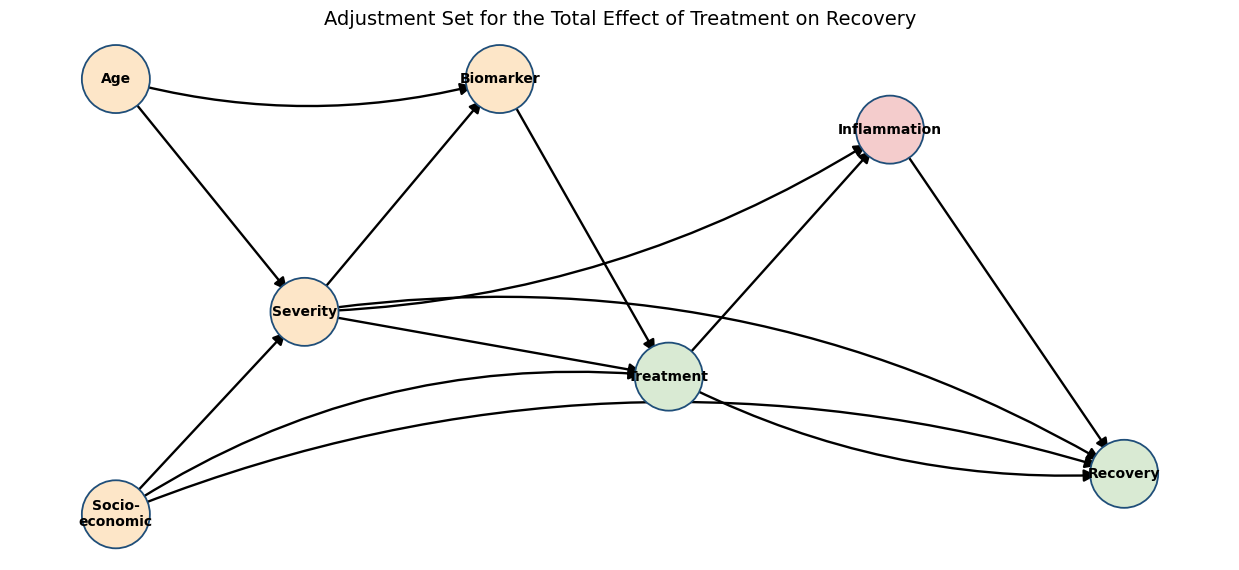

In [37]:
# DAG for Chapter 3: adjustment set for the total effect of Treatment on Recovery

edges = [
    ("Age", "Severity"),
    ("Age", "Biomarker"),
    ("Socio-\neconomic", "Severity"),
    ("Socio-\neconomic", "Treatment"),
    ("Socio-\neconomic", "Recovery"),
    ("Severity", "Biomarker"),
    ("Severity", "Treatment"),
    ("Severity", "Recovery"),
    ("Biomarker", "Treatment"),
    ("Treatment", "Recovery"),
    ("Treatment", "Inflammation"),
    ("Severity", "Inflammation"),
    ("Inflammation", "Recovery"),
]

pos = {
    "Age": (-3.0, 1.25),
    "Socio-\neconomic": (-3.0, -0.90),
    "Severity": (-1.55, 0.10),
    "Biomarker": (-0.05, 1.25),
    "Treatment": (1.25, -0.22),
    "Inflammation": (2.95, 1.00),
    "Recovery": (4.75, -0.70),
}

node_colors = {
    "Age": COLORS["light_orange"],
    "Socio-\neconomic": COLORS["light_orange"],
    "Severity": COLORS["light_orange"],
    "Biomarker": COLORS["light_orange"],
    "Treatment": COLORS["light_green"],
    "Inflammation": COLORS["light_red"],
    "Recovery": COLORS["light_green"],
}

G = nx.DiGraph()
G.add_edges_from(edges)

fig, ax = plt.subplots(figsize=(12.5, 5.8))

# Draw nodes
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=[node_colors[n] for n in G.nodes()],
    node_size=2400,
    edgecolors=COLORS["navy"],
    linewidths=1.3,
    ax=ax,
)

# Draw labels
nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_weight="bold",
    ax=ax,
)

# 1. Straight edges: local / short edges
straight_edges = [
    ("Age", "Severity"),
    ("Socio-\neconomic", "Severity"),
    ("Severity", "Biomarker"),
    ("Biomarker", "Treatment"),
    ("Severity", "Treatment"),
    ("Treatment", "Inflammation"),
    ("Inflammation", "Recovery"),
]

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=straight_edges,
    arrows=True,
    arrowsize=18,
    width=1.7,
    edge_color="black",
    connectionstyle="arc3,rad=0.0",
    min_source_margin=20,
    min_target_margin=20,
    ax=ax,
)

# 2. Curved edges above
curved_up_edges = [
    ("Age", "Biomarker"),
    ("Severity", "Inflammation"),
    ("Treatment", "Recovery"),
]

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=curved_up_edges,
    arrows=True,
    arrowsize=18,
    width=1.7,
    edge_color="black",
    connectionstyle="arc3,rad=0.14",
    min_source_margin=20,
    min_target_margin=20,
    ax=ax,
)

# 3. Curved edges below
curved_down_edges = [
    ("Socio-\neconomic", "Treatment"),
    ("Socio-\neconomic", "Recovery"),
    ("Severity", "Recovery"),
]

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=curved_down_edges,
    arrows=True,
    arrowsize=18,
    width=1.7,
    edge_color="black",
    connectionstyle="arc3,rad=-0.18",
    min_source_margin=20,
    min_target_margin=20,
    ax=ax,
)

ax.set_title("Adjustment Set for the Total Effect of Treatment on Recovery", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

</br>

---
## 3. The Fundamental Problem of Causal Inference

Causal inference is difficult because, for each patient, there are two possible outcomes:

- the outcome if the patient receives treatment,
- the outcome if the patient does not receive treatment.

But in real data, we observe only one of them.

For patient $i$, define:

$$Y_i(1)$$

as the recovery score if patient $i$ receives treatment.

Define:

$$Y_i(0)$$

as the recovery score if patient $i$ does not receive treatment.

The individual treatment effect is:

$$\tau_i = Y_i(1) - Y_i(0)$$

This compares two possible outcomes for the same patient.

But we cannot observe both outcomes at the same time.

A patient either receives treatment or does not receive treatment.

The observed outcome is:

$$Y_i = T_iY_i(1) + (1 - T_i)Y_i(0)$$

where:

- $T_i = 1$ means patient $i$ received treatment,
- $T_i = 0$ means patient $i$ did not receive treatment.

So:

| Treatment status | Observed outcome | Missing counterfactual |
|---|---|---|
| $T_i = 1$ | $Y_i(1)$ | $Y_i(0)$ |
| $T_i = 0$ | $Y_i(0)$ | $Y_i(1)$ |

The missing outcome is the **counterfactual outcome**.

It is the answer to the question:

> *What would have happened to the same patient under the other treatment condition?*

This is the **fundamental problem of causal inference**:

> For each individual, we observe only one potential outcome. The other potential outcome is missing.


This is why causal inference is different from ordinary prediction.

- Prediction estimates the outcome we observe.
- Causal inference reasons about outcomes under alternative interventions.
- Some of these outcomes are not observed for each individual.

Causal machine learning helps by combining:

- causal assumptions about treatment assignment,
- adjustment using pre-treatment variables,
- flexible models for outcome and treatment assignment,
- estimation of average and heterogeneous treatment effects.


</br>

---
## 4. Treatment Effect Estimands

Before choosing a causal machine learning method, we need to define the **estimand**.

- An **estimand** is the causal quantity we want to estimate. This is different from an **estimator**, which is the method or algorithm used to estimate that quantity from data.

In this chapter, the **treatment** is `Treatment` and the main **outcome** is `RecoveryScore`. Because the simulated dataset contains potential outcomes, we can define several treatment-effect quantities exactly.

For each patient $i$, the individual treatment effect is:

$$\tau_i = Y_i(1) - Y_i(0)$$

However, in real data, $\tau_i$ is not directly observed because we do not observe both $Y_i(1)$ and $Y_i(0)$ for the same patient.

Instead, causal inference often focuses on population-level or subgroup-level summaries.


---
### 4.1 Average Treatment Effect (ATE)

The **Average Treatment Effect** measures the average causal effect of treatment in the full population:

$$ATE = E[Y(1) - Y(0)]$$

In this example, it answers the question:

> *By how much would the average recovery score change if all patients received treatment instead of no treatment?*

Because this is a simulation, the next code cell computes the true ATE directly from the simulated potential outcomes `Y1` and `Y0`.

In real observational data, this direct calculation would not be possible. For each patient, there are two potential outcomes: the recovery score under treatment, $Y_i(1)$, and the recovery score under no treatment, $Y_i(0)$. However, we observe only the outcome corresponding to the treatment the patient actually received.

- If the patient received treatment, we observe $Y_i(1)$ and $Y_i(0)$ is missing.
- If the patient did not receive treatment, we observe $Y_i(0)$ and $Y_i(1)$ is missing.

The missing potential outcome is the **counterfactual**. Therefore, in real-world studies, the ATE must be estimated using assumptions and methods such as adjustment, matching, weighting, meta-learners, or Double Machine Learning.

In [38]:
true_ate = (health["Y1"] - health["Y0"]).mean()

print(f"True ATE: {true_ate:.3f}")

True ATE: 6.608


---
### 4.2 Average Treatment Effect on the Treated (ATT)

The **Average Treatment Effect on the Treated** measures the average causal effect among patients who actually received treatment:

$$ATT = E[Y(1) - Y(0) \mid T = 1]$$

This estimand answers:

> *Among patients who received treatment, how much did treatment improve their recovery score on average?*

- The ATT can differ from the ATE when treatment effects are heterogeneous and when treated patients differ systematically from untreated patients.
  
- In our simulated dataset, more severe patients are more likely to receive treatment, and severity also modifies the treatment effect. Therefore, the patients who actually receive treatment may have a different average treatment effect than the full patient population.

Because this is a simulation, the next code cell computes the true ATT using the simulated individual treatment effects:

$$Y_i(1) - Y_i(0)$$

for patients with $T_i = 1$.

In real observational data, this direct calculation would not be possible. For treated patients, we observe $Y(1)$, but we do not observe what their recovery score would have been without treatment, $Y(0)$. That missing untreated outcome is the counterfactual. Therefore, in real-world studies, the ATT must be estimated using causal assumptions and methods such as matching, weighting, adjustment, or causal machine learning.

In [39]:
true_att = (
    health.loc[health["Treatment"] == 1, "Y1"]
    - health.loc[health["Treatment"] == 1, "Y0"]
).mean()

print(f"True ATT: {true_att:.3f}")

True ATT: 7.177


---
### 4.3 Average Treatment Effect on the Untreated (ATU)

The **Average Treatment Effect on the Untreated** measures the average causal effect among patients who did not receive treatment:

$$ATU = E[Y(1) - Y(0) \mid T = 0]$$

This estimand answers:

> *Among patients who did not receive treatment, how much would their recovery score have changed if they had received treatment?*

- The ATU is useful when we want to evaluate whether expanding treatment to currently untreated patients would be beneficial.
  
- The ATU can differ from the ATE and ATT when treatment effects are heterogeneous and when untreated patients differ systematically from treated patients.

- In our simulated dataset, untreated patients tend to have lower baseline severity than treated patients. Since severity modifies the treatment effect, the average treatment effect among untreated patients may differ from the average effect among treated patients or the full population.

Because this is a simulation, the next code cell computes the true ATU from the simulated potential outcomes:

$$Y_i(1) - Y_i(0)$$

for patients with $T_i = 0$.

In real observational data, this direct calculation would not be possible. For untreated patients, we observe $Y(0)$, but we do not observe what their recovery score would have been if they had received treatment, $Y(1)$. That missing treated outcome is the counterfactual. Therefore, in real-world studies, the ATU must be estimated using causal assumptions and methods such as adjustment, matching, weighting, or causal machine learning.

In [40]:
true_atu = (
    health.loc[health["Treatment"] == 0, "Y1"]
    - health.loc[health["Treatment"] == 0, "Y0"]
).mean()

print(f"True ATU: {true_atu:.3f}")

True ATU: 6.152


---
### 4.4 Conditional Average Treatment Effect (CATE)

The **Conditional Average Treatment Effect** measures how the treatment effect varies across patient characteristics:

$$CATE(x) = E[Y(1) - Y(0) \mid X = x]$$

Here, $X$ represents pre-treatment covariates such as `Age`, `Severity`, `Biomarker`, and `Socioeconomic`.

This estimand answers:

> *Which types of patients benefit more or less from treatment?*

- CATE is central to causal machine learning because machine learning can help estimate treatment-effect heterogeneity in flexible ways. Instead of estimating only one average effect for the full population, causal ML methods can estimate how the expected effect changes across patient profiles.

- It is important to note that CATE is still an average quantity. It is the average treatment effect for patients with characteristics $X=x$, not necessarily the exact individual effect for one specific patient.

- In our example, CATE can help us ask whether patients with high baseline severity benefit more from treatment than patients with low baseline severity, or whether the expected treatment benefit changes with age or biomarker values.

Because this is a simulation, we know the true individual treatment effect for each patient:

$$Y_i(1) - Y_i(0)$$

In real observational data, the true individual treatment effect would not be observed. We would only observe one outcome per patient, either under treatment or under no treatment. Therefore, CATE must be estimated using causal assumptions and methods such as meta-learners, causal forests, or Double Machine Learning extensions.

---
The next code cell summarizes how these true treatment effects vary by severity group.

In [41]:
health["SeverityGroup"] = pd.qcut(
    health["Severity"],
    q=4,
    labels=["Low severity", "Medium-low", "Medium-high", "High severity"]
)

cate_by_severity = health.groupby("SeverityGroup", observed=True).agg(
    patients=("RecoveryScore", "size"),
    mean_severity=("Severity", "mean"),
    mean_true_effect=("TrueTreatmentEffect", "mean")
)

cate_by_severity.round(3)

,patients,mean_severity,mean_true_effect
SeverityGroup,,,
Low severity,750,-1.585,5.534
Medium-low,750,-0.419,6.209
Medium-high,750,0.370,6.998
High severity,750,1.554,7.690


The table above shows whether the simulated treatment effect differs across severity groups. Since the data-generating process was designed so that treatment helps more for higher-severity patients, we expect the average true treatment effect to increase with severity.

The next code cell visualizes this heterogeneity. This type of plot is useful because it moves beyond the single average treatment effect and shows how the expected benefit changes across clinically meaningful groups.

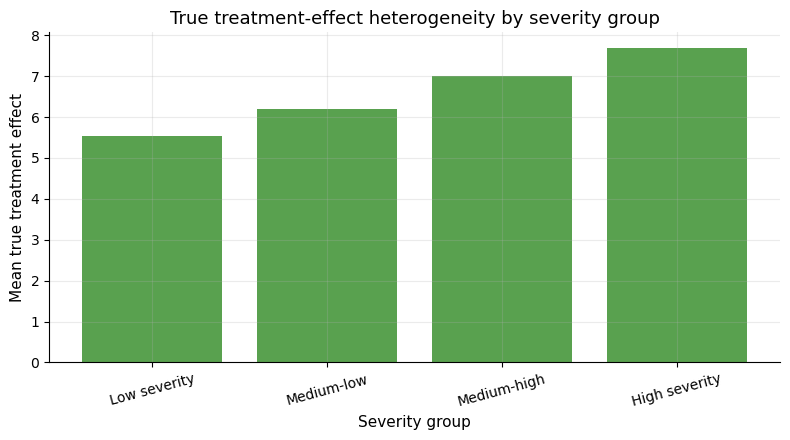

In [42]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.bar(
    cate_by_severity.index.astype(str),
    cate_by_severity["mean_true_effect"],
    color=COLORS["green"]
)

ax.set_title("True treatment-effect heterogeneity by severity group")
ax.set_xlabel("Severity group")
ax.set_ylabel("Mean true treatment effect")
clean_axis(ax)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

---
### 4.5 Why Estimands Matter

Different causal questions require different estimands.

| Estimand | Mathematical form | Question |
|---|---|---|
| ATE | $E[Y(1) - Y(0)]$ | What is the average effect in the full population? |
| ATT | $E[Y(1) - Y(0) \mid T=1]$ | What is the average effect among treated patients? |
| ATU | $E[Y(1) - Y(0) \mid T=0]$ | What would be the average effect among untreated patients if treated? |
| CATE | $E[Y(1) - Y(0) \mid X=x]$ | How does the effect vary by patient characteristics? |

The estimand should be chosen before fitting a model. Otherwise, we may estimate a quantity that does not match the scientific or decision-making question.

For example:

- If the hospital wants to know whether the treatment works overall, the ATE may be appropriate.
- If the hospital wants to evaluate whether treated patients benefited, the ATT may be more relevant.
- If the hospital wants to decide whether to expand treatment to untreated patients, the ATU may be useful.
- If the hospital wants to personalize treatment decisions, the CATE is the main target.


---
### 4.6 How to Interpret ATE, ATT, ATU, and CATE Values

Treatment-effect values are interpreted in the **unit of the outcome**.

In this chapter, the outcome is `RecoveryScore`.

Higher `RecoveryScore` means better recovery.

So:

- a **positive** treatment effect means treatment improves recovery;
- a **negative** treatment effect means treatment reduces recovery;
- the size of the number tells us how many recovery-score points change.


| Estimand | Question | Example interpretation |
|---|---|---|
| ATE | What is the average effect in the full population? | $ATE = 6$ means treatment increases the average recovery score by 6 points for all patients on average. |
| ATT | What is the average effect among treated patients? | $ATT = 7$ means treated patients gained 7 recovery-score points on average because of treatment. |
| ATU | What would be the average effect among untreated patients if treated? | $ATU = 5$ means untreated patients would gain 5 recovery-score points on average if they received treatment. |
| CATE | What is the average effect for patients with characteristics $X=x$? | $CATE(x)=8$ means patients with characteristics $x$ are expected to gain 8 recovery-score points from treatment. |

All four estimands are based on the same basic contrast:

$$Y(1) - Y(0)$$

This means:

> outcome under treatment minus outcome under no treatment.

---

### Important note about the sign

In this chapter, higher `RecoveryScore` is better.

So positive effects are good.

But this depends on the outcome.

For outcomes such as:

- `Mortality`
- `FailureRisk`
- `EnergyConsumption`
- `CO2Emissions`

lower values may be better.

In those cases, a **negative** treatment effect may be beneficial.

The practical rule is:

> First ask whether higher outcome values are good or bad. Then interpret the sign and size of the treatment effect in the unit of that outcome.

</br>

---
## 5. Why Ordinary Machine Learning Is Not Enough

Ordinary machine learning is powerful for prediction.

A predictive model usually estimates:

$$E[Y \mid T, X]$$

This asks:

> What outcome do we expect for patients with treatment status $T$ and characteristics $X$?

A causal model asks a different question:

$$E[Y \mid do(T=1)] - E[Y \mid do(T=0)]$$

This asks:

> What would happen if we actively assigned treatment instead of no treatment?

These are not the same question.

In observational data, treatment is often not randomly assigned. In our healthcare example:

- more severe patients are more likely to receive treatment;
- severity also affects recovery.

So `Treatment` is not only a treatment indicator. It also carries information about the patient’s baseline risk.

A standard ML model may use `Treatment` as a predictive feature. But it does not automatically know whether:

- treatment caused the outcome, or
- treatment is associated with patients who were already more severe.

This creates several problems.

1. **Prediction is not intervention**  
   A model trained to predict $Y$ from $T$ and $X$ learns observed associations, not necessarily causal effects.

2. **Confounding can distort the estimate**  
   If treatment depends on severity, biomarkers, or socioeconomic status, then treated and untreated patients are not directly comparable.

3. **Good prediction does not guarantee causal validity**  
   A model can predict recovery well and still give a misleading treatment-effect estimate.

4. **Regularization can shrink treatment signals**  
   Flexible ML models may smooth or ignore weak treatment-related patterns if that improves prediction.

5. **Wrong adjustment can change the estimand**  
   Post-treatment variables, such as `Inflammation`, may enter the model by mistake. If we adjust for them while estimating the total effect, we may remove part of the treatment effect.

There is also the issue of **heterogeneity**.

The practical lesson is:

> A machine learning model may have low prediction error but still answer the wrong causal question.

This is why causal machine learning starts with causal design. We first define the causal question, estimand, adjustment strategy, and assumptions. Then we use machine learning to estimate the needed functions more flexibly.

---
### 5.1 A Predictive Machine Learning Model

The next code cell fits a standard random forest model.

The goal is to predict `RecoveryScore` using:

- `Treatment`
- pre-treatment covariates `X`

This is a prediction task. The model tries to minimize prediction error for the observed outcome:

$$\hat{f}(T, X) \approx E[RecoveryScore \mid T, X]$$

But this is not the same as estimating the causal effect of treatment:

$$E[RecoveryScore \mid do(Treatment=1)] - E[RecoveryScore \mid do(Treatment=0)]$$

So the main point is:

> Good prediction does not mean the model has learned the causal effect of treatment.

In [43]:
# Features used for prediction
predictive_features = ["Treatment", "Age", "Socioeconomic", "Severity", "Biomarker"]

X = health[predictive_features]
y = health["RecoveryScore"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

rf_predictive = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=10,
    random_state=42
)

rf_predictive.fit(X_train, y_train)

y_pred = rf_predictive.predict(X_test)

# Compatible with older and newer scikit-learn versions
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Predictive RMSE: {rmse:.3f}")
print(f"Predictive R²: {r2:.3f}")

Predictive RMSE: 4.267
Predictive R²: 0.820


### Interpretation

The random forest predicts observed recovery scores reasonably well:

- RMSE = 4.267
- $R^2 = 0.820$

This means the model captures much of the observed variation in `RecoveryScore`.

However, this is still a prediction result. It does not show that the model has estimated the causal effect of treatment.

In this dataset, treatment assignment is confounded. Patients who receive treatment tend to be more severe at baseline. So the model may use `Treatment` partly as a signal of baseline risk.

The key lesson is:

> Good predictive performance is useful, but it is not evidence of a valid causal effect estimate.

---
### 5.2 Feature Importance Is Not Causal Importance

<div style="color:#1f4e79; background-color:#eef5fb; border-left:4px solid #1f4e79; padding:10px 14px; margin:12px 0;">

<strong>Optional self-study.</strong><br>
If time is limited, we may skip this section in class. Please review it independently and run the code cells.

</div>

The next code cell plots feature importance from the random forest model.

Feature importance tells us which variables helped the model predict `RecoveryScore`.

But it does **not** tell us:

- which variables cause the outcome,
- which variables should be adjusted for,
- or what the causal effect of `Treatment` is.

This distinction is important.

A variable may be important for prediction because it is:

- a true cause,
- a proxy for another variable,
- a confounder,
- or part of the treatment assignment process.

Also, a causally important variable may look less important if:

- its effect is small,
- its effect is heterogeneous,
- or it is correlated with other predictors.

The key message is:

> Predictive importance is not the same as causal importance.

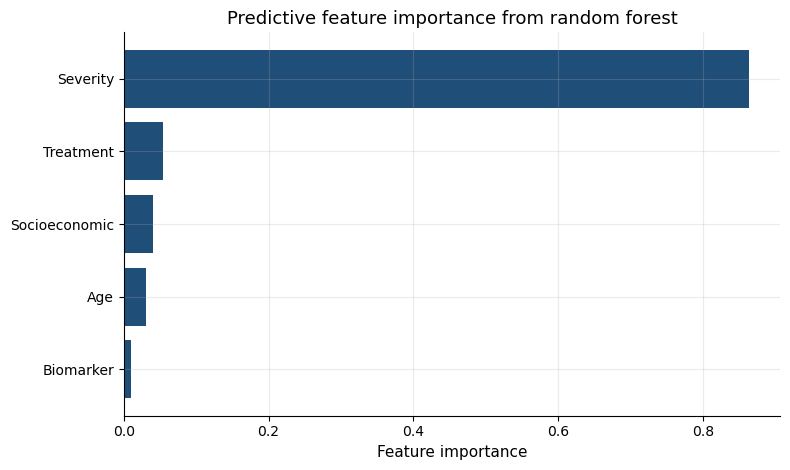

In [44]:
importances = pd.Series(
    rf_predictive.feature_importances_,
    index=predictive_features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4.8))

ax.barh(importances.index, importances.values, color=COLORS["navy"])
ax.set_title("Predictive feature importance from random forest")
ax.set_xlabel("Feature importance")
clean_axis(ax)

plt.tight_layout()
plt.show()

### Interpretation

The plot shows which variables the random forest used most for prediction.

The main result is clear:

- `Severity` is the strongest predictive feature.
- This makes sense because baseline severity strongly affects recovery.
- `Treatment` also has some predictive importance.
- But this does **not** mean the bar shows the causal effect of treatment.

Why?

In this observational dataset, treatment is more common among severe patients. So `Treatment` partly reflects the treatment itself, but also the selection process: who was more likely to receive treatment.

`Biomarker` has low importance here, even though it matters in the data-generating process. This can happen because `Biomarker` is correlated with `Severity`. Once the model uses `Severity`, the extra predictive value of `Biomarker` becomes smaller.

The key lesson is:

> Predictive importance is not the same as causal importance.

For causal effect estimation, the question is not only:

> Which variables predict `RecoveryScore`?

The real question is:

> Which variables are needed for a valid adjustment strategy?

---
### 5.3 Naive Treatment Comparison from Observed Data

<div style="color:#1f4e79; background-color:#eef5fb; border-left:4px solid #1f4e79; padding:10px 14px; margin:12px 0;">

<strong>Optional self-study.</strong><br>
If time is limited, we may skip this section in class. Please review it independently and run the code cells.

</div>


The next code cell computes the raw difference in mean recovery score:

$$E[Y \mid T=1] - E[Y \mid T=0]$$

This compares:

- patients who received treatment,
- patients who did not receive treatment.

This is an **associational comparison**.

It does not compare the same population under two interventions:

$$do(T=1)$$

and:

$$do(T=0)$$

So, if treatment assignment is confounded, this number should not be interpreted as a causal effect.

The key point is:

> A raw treated-versus-untreated comparison is not the same as an intervention.

In [45]:
observed_treated_mean = health.loc[health["Treatment"] == 1, "RecoveryScore"].mean()
observed_untreated_mean = health.loc[health["Treatment"] == 0, "RecoveryScore"].mean()
naive_difference = observed_treated_mean - observed_untreated_mean

print(f"Observed mean recovery score, treated:   {observed_treated_mean:.3f}")
print(f"Observed mean recovery score, untreated: {observed_untreated_mean:.3f}")
print(f"Naive observed difference:               {naive_difference:.3f}")

Observed mean recovery score, treated:   72.733
Observed mean recovery score, untreated: 77.732
Naive observed difference:               -4.999


### Interpretation

The naive comparison gives:

$$72.7 - 77.7 \approx -5.0$$

At first glance, this suggests that treated patients recover about 5 points less than untreated patients.

But this is misleading.

The two groups are not comparable before treatment:

- treated patients are more severe at baseline;
- higher severity reduces recovery;
- so treated patients start from a worse health condition.

The naive comparison mixes:

1. the possible effect of treatment,
2. baseline differences between treated and untreated patients.

The problem is not the calculation.

The problem is the causal design:

> Treated and untreated patients were already different before treatment.

This is why we need adjustment, matching, weighting, or causal ML methods that compare patients with similar pre-treatment characteristics.

---
### 5.4 Comparing the Naive Association with the True Causal Effect

<div style="color:#1f4e79; background-color:#eef5fb; border-left:4px solid #1f4e79; padding:10px 14px; margin:12px 0;">

<strong>Optional self-study.</strong><br>
If time is limited, we may skip this section in class. Please review it independently and run the code cells.

</div>

Because this is a simulation, we know the true potential outcomes:

- `Y0`: recovery score under no treatment,
- `Y1`: recovery score under treatment.

So we can compute the true Average Treatment Effect:

$$ATE = E[Y(1) - Y(0)]$$

The next code cell compares two quantities:

1. the naive observed difference,
2. the true simulated ATE.

This comparison is possible only because the data are simulated.

In real observational data, we would observe only one realized outcome for each patient. The other potential outcome would be missing as the counterfactual.

In [46]:
true_ate = (health["Y1"] - health["Y0"]).mean()

comparison = pd.DataFrame({
    "Quantity": [
        "Naive observed difference",
        "True ATE from simulated potential outcomes"
    ],
    "Value": [
        naive_difference,
        true_ate
    ]
})

comparison.round(3)

,Quantity,Value
0,Naive observed difference,-4.999
1,True ATE from simulated potential outcomes,6.608


### Interpretation

The table compares two quantities.

The naive observed difference is about:

$$-5.0$$

This suggests that treated patients have recovery scores about 5 points lower than untreated patients.

But the true ATE is about:

$$6.6$$

This means that treatment actually increases recovery by about 6.6 points on average in the simulation.

So the naive association and the true causal effect have opposite signs.

Why?

Because treated patients are more severe at baseline. Their observed recovery scores are lower, even though the treatment itself is beneficial.

The key lesson is:

> The observed association can point in the wrong direction when treatment assignment is confounded.

This is why we need causal design, adjustment variables, and clear estimands before using causal ML methods.

---
### 5.5 Why Not Just Use the Predictive Model to Simulate Treatment?

A common idea is:

1. fit a predictive model;
2. set `Treatment = 1` for everyone;
3. set `Treatment = 0` for everyone;
4. compare the two predictions.

This gives a model-based contrast:

$$\hat{E}[Y \mid T=1, X] - \hat{E}[Y \mid T=0, X]$$

This is better than a raw treated-versus-untreated comparison because each patient is evaluated twice:

- once as if treated,
- once as if untreated.

However, this contrast is not automatically causal.

The next code cell uses the predictive random forest model to estimate this treatment contrast while keeping pre-treatment covariates fixed.

In [47]:
X_do1 = health[predictive_features].copy()
X_do0 = health[predictive_features].copy()

X_do1["Treatment"] = 1
X_do0["Treatment"] = 0

rf_do1 = rf_predictive.predict(X_do1)
rf_do0 = rf_predictive.predict(X_do0)

rf_plugin_effect = np.mean(rf_do1 - rf_do0)

print(f"Random forest plug-in treatment-effect estimate: {rf_plugin_effect:.3f}")
print(f"True ATE:                                      {true_ate:.3f}")

Random forest plug-in treatment-effect estimate: 5.048
True ATE:                                      6.608


### Interpretation

The random forest plug-in estimate is about:

$$5.05$$

The true ATE is about:

$$6.61$$

So the plug-in approach gets the direction right:

> Treatment is estimated to improve recovery.

This is much better than the naive comparison, which suggested a negative effect.

However, the plug-in estimate is still lower than the true causal effect.

Why?

The random forest was trained for prediction, not specifically for causal effect estimation. It learned the observed outcome pattern:

$$\hat{f}(T, X) \approx E[RecoveryScore \mid T, X]$$

Then we used it to compare two predicted scenarios:

- the same patients as if treated,
- the same patients as if untreated.

This is closer to causal reasoning than a raw group comparison.

The key lesson is:

> Simulating treatment with a predictive model is useful, but it is not automatically a valid causal estimator.

This motivates methods designed more directly for treatment-effect estimation, such as meta-learners and Double Machine Learning.

</br>

---
## 6. Baseline Estimators: Naive Comparison and Adjusted Outcome Modeling

Section 5 showed that ordinary machine learning can predict observed outcomes, but prediction is not the same as causal effect estimation.

We now introduce two simple baseline estimators.

1. **Naive difference in means**

This compares observed treated and untreated patients:

$$\hat{\tau}_{naive} = E[Y \mid T=1] - E[Y \mid T=0]$$

This is simple, but it may be confounded.

2. **Adjusted outcome modeling**

This fits an outcome model using treatment and pre-treatment covariates:

$$\hat{m}(T, X) \approx E[Y \mid T, X]$$

Then we predict each patient twice:

- once as treated,
- once as untreated.

The estimated effect is:

$$\frac{1}{n}\sum_{i=1}^{n}
\left[
\hat{m}(1, X_i) - \hat{m}(0, X_i)
\right]$$

This approach is also called **model-based standardization** or **g-computation**.

It is closer to the causal question because it compares treatment and no treatment over the same distribution of pre-treatment covariates.

However, it is credible only if:

- the adjustment set is appropriate,
- important confounders are not omitted,
- the outcome model is reasonable.

---
### 6.1 Define the Adjustment Set

The next code cell defines the pre-treatment variables used for adjustment.

These variables are measured before treatment and help explain both:

- who receives treatment,
- and patient recovery.

We use the same adjustment logic from the DAG:

$$X = \{Age, Socioeconomic, Severity, Biomarker\}$$

We exclude `Inflammation` because it is post-treatment. Including it would change the estimand from the total effect toward a direct-effect-style quantity.

In [48]:
# Pre-treatment adjustment variables
adjustment_vars = ["Age", "Socioeconomic", "Severity", "Biomarker"]

print("Adjustment variables:")
for var in adjustment_vars:
    print(f"- {var}")

print("\nExcluded from total-effect adjustment:")
print("- Inflammation: post-treatment mediator")

Adjustment variables:
- Age
- Socioeconomic
- Severity
- Biomarker

Excluded from total-effect adjustment:
- Inflammation: post-treatment mediator


### Interpretation

- The adjustment set contains only pre-treatment variables.

- These variables help make the treated and untreated groups more comparable.

- We do not adjust for `Inflammation` because it happens after treatment and may carry part of the treatment effect.

---
### 6.2 Naive Difference in Means

The next code cell computes the naive difference in mean recovery score:

$$E[RecoveryScore \mid Treatment=1] - E[RecoveryScore \mid Treatment=0]$$

This compares the patients who happened to receive treatment with the patients who did not.

It is a useful diagnostic baseline, but it is not automatically causal.

In [49]:
# Naive observed difference in mean recovery score
naive_effect = (
    health.loc[health["Treatment"] == 1, "RecoveryScore"].mean()
    - health.loc[health["Treatment"] == 0, "RecoveryScore"].mean()
)

print(f"Naive observed difference: {naive_effect:.3f}")

Naive observed difference: -4.999


### Interpretation

The naive difference is negative.

At first glance, this would suggest that treatment reduces recovery.

But this is misleading.

In this simulated observational dataset, treated patients are more severe at baseline. Since severity strongly reduces recovery, the treated group starts from a worse health condition.

The naive estimate mixes two things:

1. the possible causal effect of treatment,
2. baseline differences between treated and untreated patients.

The key lesson is:

> The naive difference is simple, but it is not a credible causal estimate when treated and untreated patients differ before treatment.

---
### 6.3 Adjusted Linear Outcome Model

The next code cell fits a simple linear outcome model:

$$\hat{m}(T, X) = \hat{E}[Y \mid T, X]$$

where:

- $Y$ is `RecoveryScore`,
- $T$ is `Treatment`,
- $X$ contains the pre-treatment adjustment variables.

After fitting the model, we create two hypothetical versions of the same dataset:

- one where every patient is assigned treatment: `Treatment = 1`,
- one where every patient is assigned no treatment: `Treatment = 0`.

All pre-treatment covariates stay the same.

This lets us compare treatment and no treatment for the same patient population.

In [50]:
# Linear adjusted outcome model
lin_model = LinearRegression()

lin_model.fit(
    health[["Treatment"] + adjustment_vars],
    health["RecoveryScore"]
)

# Create two hypothetical intervention datasets
do1 = health.copy()
do0 = health.copy()

do1["Treatment"] = 1
do0["Treatment"] = 0

# Predict recovery score under each intervention
lin_do1 = lin_model.predict(do1[["Treatment"] + adjustment_vars]).mean()
lin_do0 = lin_model.predict(do0[["Treatment"] + adjustment_vars]).mean()

lin_adjusted_effect = lin_do1 - lin_do0

print(f"Predicted mean recovery score under do(Treatment=1): {lin_do1:.3f}")
print(f"Predicted mean recovery score under do(Treatment=0): {lin_do0:.3f}")
print(f"Adjusted linear outcome-model estimate: {lin_adjusted_effect:.3f}")

Predicted mean recovery score under do(Treatment=1): 79.391
Predicted mean recovery score under do(Treatment=0): 72.409
Adjusted linear outcome-model estimate: 6.983


### Interpretation

The adjusted model predicts two mean outcomes for the same patient population:

$$\hat{E}[Y \mid do(T=1)]$$

and:

$$\hat{E}[Y \mid do(T=0)]$$

The difference is the adjusted treatment-effect estimate.

In this simulation, the adjusted estimate is positive and much closer to the true ATE than the naive comparison.

This shows the value of adjustment:

> Instead of comparing different groups of patients, we compare treatment and no treatment over the same covariate distribution.

This is still a baseline estimator. It depends on the adjustment set and on the linear model being a reasonable approximation.

---
### 6.4 Compare Baseline Estimators with the True ATE

Because this is a simulation, we can compare the baseline estimates with the true ATE.

In real observational data, the true ATE would not be available.

Here, we use it only for teaching and evaluation.

In [51]:
baseline_results = pd.DataFrame({
    "Estimator": [
        "Naive difference",
        "Adjusted linear outcome model",
        "True ATE"
    ],
    "Estimated ATE": [
        naive_effect,
        lin_adjusted_effect,
        true_ate
    ]
})

baseline_results["Absolute error vs true ATE"] = (
    baseline_results["Estimated ATE"] - true_ate
).abs()

baseline_results.round(3)

,Estimator,Estimated ATE,Absolute error vs true ATE
0,Naive difference,-4.999,11.606
1,Adjusted linear outcome model,6.983,0.375
2,True ATE,6.608,0.000


### Interpretation

The table compares three quantities.

- The naive difference has the wrong sign. It suggests a negative effect because treated patients are more severe at baseline.

- The adjusted linear model is much closer to the true ATE. After adjustment, the estimate becomes positive and close to the simulated causal effect.

- The `Absolute error vs true ATE` column is available only because this is a simulation.

In real studies, we would not know the true ATE. We would rely on causal assumptions, diagnostics, sensitivity analysis, and domain knowledge.

---
### 6.5 Visual Summary of Baseline Estimators

The next code cell visualizes the same comparison.

The dashed line marks the true ATE from the simulation.

The goal is to show how adjustment moves the estimate from a misleading association toward the causal target.

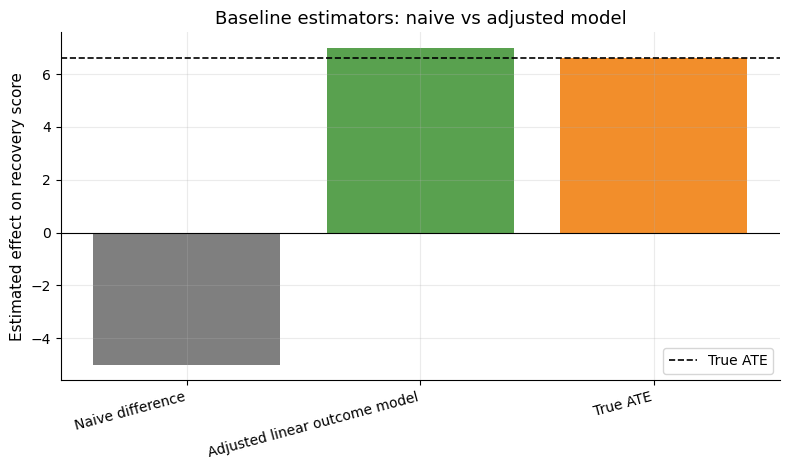

In [52]:
fig, ax = plt.subplots(figsize=(8, 4.8))

ax.bar(
    baseline_results["Estimator"],
    baseline_results["Estimated ATE"],
    color=[COLORS["gray"], COLORS["green"], COLORS["orange"]]
)

ax.axhline(
    true_ate,
    color="black",
    linewidth=1.2,
    linestyle="--",
    label="True ATE"
)

ax.axhline(0, color="black", linewidth=0.8)

ax.set_title("Baseline estimators: naive vs adjusted model")
ax.set_ylabel("Estimated effect on recovery score")
ax.legend()

plt.xticks(rotation=15, ha="right")
clean_axis(ax)
plt.tight_layout()
plt.show()

### Interpretation

The figure gives a quick visual summary.

- The gray bar shows the naive difference. It is below zero and gives the wrong causal direction.
- The green bar shows the adjusted outcome-model estimate. It is close to the true ATE.
- The orange bar shows the true ATE, which is known only because this is a simulation.

The main lesson is:

> Adjustment can move a misleading observational comparison closer to the causal target.

But the adjusted linear model is still only a baseline. It may be too simple when relationships are nonlinear or treatment effects vary across patients.

---
### 6.6 What This Baseline Teaches Us

| Estimator | What it does | Main strength | Main limitation |
|---|---|---|---|
| Naive difference | Compares observed treated and untreated means | Simple and transparent | Biased when treatment assignment is confounded |
| Adjusted outcome model | Predicts outcomes under treatment and no treatment after adjusting for $X$ | Connects directly to backdoor adjustment and standardization | Sensitive to omitted confounders and model misspecification |
| True ATE | Uses simulated potential outcomes | Useful for teaching and evaluation | Not available in real observational data |

The baseline estimators provide the bridge from causal design to causal machine learning.

The naive estimator is a warning. It shows what can go wrong without adjustment.

The adjusted outcome model is a first causal baseline. It compares treatment and no treatment over the same covariate distribution.

However, the adjusted linear model is limited when:

- the outcome relationship is nonlinear,
- treatment effects vary across patients,
- the treatment assignment process is complex,
- covariates are high-dimensional.

These limitations motivate the next section on meta-learners.

</br>

---
## 7. Meta-Learners for Outcome Modeling: S-Learner, T-Learner, and X-Learner

Section 6 introduced adjusted outcome modeling.

The idea was to predict two outcomes for the same patient:

$$\hat{m}(1, X_i) - \hat{m}(0, X_i)$$

This is useful, but the linear model in Section 6 is simple. Real data may be more complex:

- the outcome relationship may be nonlinear;
- the treatment effect may vary across patients;
- different subgroups may respond differently to treatment.

Meta-learners extend the same idea using machine learning models.

They are called **meta-learners** because they are not one specific algorithm. They are strategies for organizing prediction models around causal effect estimation.

The main target is the Conditional Average Treatment Effect, or CATE:

$$\tau(x) = E[Y(1) - Y(0) \mid X=x]$$

Here, $X$ contains pre-treatment variables such as:

- `Age`
- `Socioeconomic`
- `Severity`
- `Biomarker`

In simple terms, CATE asks:

> *For patients with characteristics $X=x$, how much would treatment change the expected recovery score?*

In this section, we study three common meta-learners:

| Learner | Main idea |
|---|---|
| S-learner | Fit one outcome model using treatment and covariates together |
| T-learner | Fit separate outcome models for treated and untreated patients |
| X-learner | Impute treatment effects, then model those effects |

</br>

All three methods use machine learning for prediction. But their goal is not ordinary prediction. Their goal is to estimate causal contrasts such as:

$$\hat{Y}(1 \mid X=x) - \hat{Y}(0 \mid X=x)$$

The causal assumptions remain the same:

- the adjustment variables must be measured before treatment;
- important confounders should be included in $X$;
- treated and untreated patients should have sufficient overlap.

The practical message is:

> Meta-learners use prediction models, but their purpose is causal effect estimation.

---
### 7.1 Prepare Variables for Meta-learners

The next code cell defines the common variables used by all three meta-learners.

We use the same pre-treatment adjustment variables as in Section 6:

- `Age`
- `Socioeconomic`
- `Severity`
- `Biomarker`

The outcome is `RecoveryScore`, and the treatment is `Treatment`.

This keeps the causal design consistent across sections: we estimate the total effect of treatment and avoid post-treatment variables such as `Inflammation`.

In [53]:
X_cov = health[adjustment_vars]
T = health["Treatment"].values
Y = health["RecoveryScore"].values

print("Covariates used for meta-learners:")
for var in adjustment_vars:
    print(f"- {var}")

print(f"\nOutcome: RecoveryScore")
print(f"Treatment: Treatment")
print(f"Number of patients: {len(health)}")
print(f"Treatment rate: {T.mean():.3f}")

Covariates used for meta-learners:
- Age
- Socioeconomic
- Severity
- Biomarker

Outcome: RecoveryScore
Treatment: Treatment
Number of patients: 3000
Treatment rate: 0.444


### Interpretation

The output confirms the variables used for the meta-learner estimators.

The covariates are `Age`, `Socioeconomic`, `Severity`, and `Biomarker`. These are all measured before treatment, so they are appropriate adjustment variables for estimating the total effect of `Treatment` on `RecoveryScore`.

The treatment rate is about **0.44**, meaning that approximately **44%** of patients received treatment. This does not mean treatment was randomly assigned. In the simulated dataset, treatment assignment depends on patient severity and biomarker values, so treated and untreated patients still differ systematically.

---
### 7.2 S-Learner

The **S-learner** uses one outcome model.

It fits a model using both:

- treatment,
- pre-treatment covariates.

The model is:

$$\hat{m}(T, X) \approx E[Y \mid T, X]$$

After fitting the model, we predict two outcomes for each patient.

First, predicted outcome under treatment:

$$\hat{Y}(1 \mid X=x) = \hat{m}(1, x)$$

Then, predicted outcome under no treatment:

$$\hat{Y}(0 \mid X=x) = \hat{m}(0, x)$$

The estimated treatment effect is the difference:

$$\hat{\tau}^{S}(x) = \hat{m}(1, x) - \hat{m}(0, x)$$

The name “S-learner” comes from the fact that it uses a **single** model.

The main advantage is simplicity.

The main limitation is that `Treatment` is only one feature in one predictive model. If other variables are much stronger predictors, the model may shrink or smooth the treatment effect.

This can be a problem when:

- the treatment signal is weak,
- treatment effects are heterogeneous,
- regularization smooths over subgroup differences.

The next code cell implements an S-learner using a random forest outcome model.

In [54]:
# S-learner with one random forest outcome model
s_features = ["Treatment"] + adjustment_vars

s_learner = RandomForestRegressor(
    n_estimators=120,
    min_samples_leaf=20,
    random_state=42
)

# Fit one model using both treatment and pre-treatment covariates
s_learner.fit(health[s_features], Y)

# Predict each patient twice: once as treated and once as untreated
s_do1 = health[s_features].copy()
s_do0 = health[s_features].copy()

s_do1["Treatment"] = 1
s_do0["Treatment"] = 0

health["CATE_S_learner"] = s_learner.predict(s_do1) - s_learner.predict(s_do0)

s_ate = health["CATE_S_learner"].mean()

print(f"S-learner estimated ATE: {s_ate:.3f}")
print(f"True ATE:                {true_ate:.3f}")

S-learner estimated ATE: 5.097
True ATE:                6.608


### Interpretation

The S-learner estimates a positive average treatment effect, so it recovers the correct direction: treatment is predicted to improve recovery.

However, the estimate is lower than the true ATE in this simulation. This can happen because the S-learner uses one outcome model where `Treatment` is only one feature among strong predictors such as `Severity` and `Biomarker`.

Since the model is optimized for prediction, it may smooth or understate the treatment contrast, especially when treatment effects are heterogeneous.

The key lesson is:

> The S-learner is simple and intuitive, but it can underestimate treatment effects when the treatment signal is weaker than other predictive signals.

---
### 7.3 T-Learner

The **T-learner** uses two separate outcome models:

- one model for treated patients,
- one model for untreated patients.

For treated patients, it estimates:

$$\hat{m}_1(x) \approx E[Y \mid T=1, X=x]$$

This means:

> Expected outcome for patients with characteristics $x$ if they receive treatment.

For untreated patients, it estimates:

$$\hat{m}_0(x) \approx E[Y \mid T=0, X=x]$$

This means:

> Expected outcome for patients with characteristics $x$ if they do not receive treatment.

The estimated treatment effect is the difference between the two predictions:

$$\hat{\tau}^{T}(x) = \hat{m}_1(x) - \hat{m}_0(x)$$

In this chapter, this means:

> predicted recovery under treatment minus predicted recovery under no treatment.

The name “T-learner” comes from the fact that it uses **two** models.

The main advantage is flexibility. The treated and untreated outcome surfaces can have different shapes.

The main limitation is data support. Each model is trained on only one treatment group. If treated and untreated patients are very different, the model may need to extrapolate when predicting counterfactual outcomes.

The next code cell implements a T-learner using two random forest outcome models.

In [55]:
# T-learner with two random forest outcome models
model_treated = RandomForestRegressor(
    n_estimators=120,
    min_samples_leaf=20,
    random_state=42
)

model_control = RandomForestRegressor(
    n_estimators=120,
    min_samples_leaf=20,
    random_state=43
)

# Fit one model among treated patients
model_treated.fit(
    health.loc[health["Treatment"] == 1, adjustment_vars],
    health.loc[health["Treatment"] == 1, "RecoveryScore"]
)

# Fit one model among untreated patients
model_control.fit(
    health.loc[health["Treatment"] == 0, adjustment_vars],
    health.loc[health["Treatment"] == 0, "RecoveryScore"]
)

# Predict potential outcomes for every patient
mu1_hat = model_treated.predict(health[adjustment_vars])
mu0_hat = model_control.predict(health[adjustment_vars])

health["CATE_T_learner"] = mu1_hat - mu0_hat

t_ate = health["CATE_T_learner"].mean()

print(f"T-learner estimated ATE: {t_ate:.3f}")
print(f"True ATE:                {true_ate:.3f}")

T-learner estimated ATE: 5.557
True ATE:                6.608


### Interpretation

The T-learner estimates a positive average treatment effect, so it recovers the correct direction: treatment is predicted to improve recovery.

Its estimate is closer to the true ATE than the S-learner estimate in this run, but it still underestimates the true effect.

The T-learner is more flexible because it fits two separate outcome models:

- one model for treated patients,
- one model for untreated patients.

This flexibility helps when treatment changes the shape of the outcome relationship. However, each model is trained on only part of the data. If treated and untreated patients differ strongly in severity or biomarker profiles, the model may need to predict counterfactual outcomes in regions where it has fewer examples.

The key lesson is:

> The T-learner can capture more flexible treatment-response patterns than the S-learner, but it needs good overlap between treated and untreated patients across the covariate space.

---
### 7.4 X-Learner

The **X-learner** is useful when:

- treatment effects are heterogeneous,
- treated and untreated groups are imbalanced.

It starts like the T-learner.

First, it fits two outcome models.

For treated patients:

$$\hat{m}_1(x) \approx E[Y \mid T=1, X=x]$$

For untreated patients:

$$\hat{m}_0(x) \approx E[Y \mid T=0, X=x]$$

Then the X-learner does something different.

It uses these two models to estimate the missing counterfactual outcome for each group. This gives **imputed treatment effects**.

For treated patients, we observe the treated outcome, but not the untreated outcome.

So we estimate the missing untreated outcome using the control model:

$$\tilde{D}_i^1 = Y_i - \hat{m}_0(X_i)$$

Read this as:

> observed treated outcome minus predicted untreated outcome.

For untreated patients, we observe the untreated outcome, but not the treated outcome.

So we estimate the missing treated outcome using the treated model:

$$\tilde{D}_i^0 = \hat{m}_1(X_i) - Y_i$$

Read this as:

> predicted treated outcome minus observed untreated outcome.

The X-learner then models these imputed treatment effects.

</br>

Finally, it combines the two treatment-effect models using the estimated **propensity score**.

The propensity score is the probability that a patient receives treatment, given their pre-treatment characteristics:

$$\hat{e}(x) = P(T=1 \mid X=x)$$

A common combination rule is:

$$\hat{\tau}^{X}(x) = (1-\hat{e}(x))\hat{\tau}_1(x) + \hat{e}(x)\hat{\tau}_0(x)$$

The next code cell implements a teaching version of the X-learner using random forests.

In [56]:
# X-learner implementation for teaching
# Step 1: reuse outcome models from the T-learner

# Step 2: impute treatment effects for treated patients
D_treated = (
    health.loc[health["Treatment"] == 1, "RecoveryScore"].values
    - model_control.predict(health.loc[health["Treatment"] == 1, adjustment_vars])
)

# Step 2: impute treatment effects for untreated patients
D_control = (
    model_treated.predict(health.loc[health["Treatment"] == 0, adjustment_vars])
    - health.loc[health["Treatment"] == 0, "RecoveryScore"].values
)

# Step 3: model the imputed treatment effects
tau_model_treated = RandomForestRegressor(
    n_estimators=120,
    min_samples_leaf=20,
    random_state=44
)

tau_model_control = RandomForestRegressor(
    n_estimators=120,
    min_samples_leaf=20,
    random_state=45
)

tau_model_treated.fit(
    health.loc[health["Treatment"] == 1, adjustment_vars],
    D_treated
)

tau_model_control.fit(
    health.loc[health["Treatment"] == 0, adjustment_vars],
    D_control
)

# Estimate propensity scores
propensity_model = RandomForestClassifier(
    n_estimators=120,
    min_samples_leaf=20,
    random_state=46
)

propensity_model.fit(health[adjustment_vars], health["Treatment"])
propensity_hat = propensity_model.predict_proba(health[adjustment_vars])[:, 1]

# Combine the two treatment-effect models
tau1_hat = tau_model_treated.predict(health[adjustment_vars])
tau0_hat = tau_model_control.predict(health[adjustment_vars])

health["CATE_X_learner"] = (1 - propensity_hat) * tau1_hat + propensity_hat * tau0_hat

x_ate = health["CATE_X_learner"].mean()

print(f"X-learner estimated ATE: {x_ate:.3f}")
print(f"True ATE:                {true_ate:.3f}")

X-learner estimated ATE: 6.713
True ATE:                6.608


### Interpretation

The X-learner estimate is very close to the true ATE in this simulation.

Unlike the S-learner and T-learner, the X-learner explicitly constructs imputed treatment effects. It first estimates missing counterfactual outcomes, then models the treatment-effect signal directly.

The propensity score is used to combine the two treatment-effect models. Intuitively, this gives more weight to the estimate that is expected to be more reliable for a given patient profile.

In this example, the X-learner performs well because treatment effects are heterogeneous and treatment assignment is not balanced across severity levels.

The key lesson is:

> The X-learner can work well when treatment effects vary across patients and treated and untreated groups are imbalanced, but it is more complex and depends on several fitted models.

---
### 7.5 Compare Meta-Learner ATE Estimates

<div style="color:#1f4e79; background-color:#eef5fb; border-left:4px solid #1f4e79; padding:10px 14px; margin:12px 0;">

<strong>Optional self-study.</strong><br>
If time is limited, we may skip this section in class. Please review it independently and run the code cells.

</div>


The next code cell compares the average treatment-effect estimates from the three meta-learners.

Each method estimates a CATE for every patient:

$$\hat{\tau}(X_i)$$

To summarize each method, we average these CATE estimates:

$$\widehat{ATE} = \frac{1}{n}\sum_{i=1}^{n}\hat{\tau}(X_i)$$

Because this is a simulation, we can compare the estimates with the true ATE.

In real data, the true ATE would not be known. Instead, we would rely on:

- robustness checks,
- overlap diagnostics,
- uncertainty intervals,
- sensitivity analysis,
- domain plausibility.

The goal is not to find a perfect number. The goal is to see whether different reasonable methods give a consistent causal story.

In [57]:
meta_learner_results = pd.DataFrame({
    "Meta-learner": [
        "S-learner",
        "T-learner",
        "X-learner",
        "True ATE"
    ],
    "Estimated ATE": [
        s_ate,
        t_ate,
        x_ate,
        true_ate
    ]
})

meta_learner_results["Absolute error vs true ATE"] = (
    meta_learner_results["Estimated ATE"] - true_ate
).abs()

meta_learner_results.round(3)

,Meta-learner,Estimated ATE,Absolute error vs true ATE
0,S-learner,5.097,1.510
1,T-learner,5.557,1.050
2,X-learner,6.713,0.105
3,True ATE,6.608,0.000


### Interpretation

The table compares the average treatment-effect estimates from the three meta-learners.

All three methods estimate a positive effect, so they agree on the main qualitative conclusion: treatment improves recovery on average.

However, the estimates differ in magnitude:

- the S-learner underestimates the true ATE;
- the T-learner is closer, but still underestimates the effect;
- the X-learner is closest to the true ATE in this simulation.

This difference occurs because the learners organize the estimation problem differently. The S-learner uses one shared outcome model, the T-learner uses two separate outcome models, and the X-learner models imputed treatment effects more directly.

The `Absolute error vs true ATE` column is available only because this is a simulation. In real observational studies, the true ATE is unknown. We would instead rely on overlap diagnostics, sensitivity analysis, uncertainty estimates, subgroup stability, and domain knowledge.

The key lesson is:

> Meta-learners can agree on the direction of the treatment effect while still producing different numerical estimates.

---
### 7.6 Summary of Meta-Learners

<div style="color:#1f4e79; background-color:#eef5fb; border-left:4px solid #1f4e79; padding:10px 14px; margin:12px 0;">

<strong>Optional self-study.</strong><br>
If time is limited, we may skip this section in class. Please review it independently and run the code cells.

</div>

| Learner | Main idea | Strength | Limitation |
|---|---|---|---|
| S-learner | Fit one model $\hat{m}(T, X)$ and compare predictions under $T=1$ and $T=0$ | Simple and easy to implement | May smooth or shrink treatment effects |
| T-learner | Fit separate models $\hat{m}_1(X)$ and $\hat{m}_0(X)$ | Allows different outcome surfaces for treated and untreated patients | Sensitive to weak overlap or small sample size in one group |
| X-learner | Impute treatment effects, model them, and combine using propensity scores | Useful for heterogeneous effects and imbalanced groups | More complex and depends on several fitted models |

Meta-learners are not tied to one machine learning algorithm.

In this chapter, we used random forests because they are flexible and work well for nonlinear tabular examples.

But the same S-, T-, and X-learner strategies can use other supervised learning models.

| ML model | When it can be useful |
|---|---|
| Linear or regularized regression | When interpretability is important and relationships are close to linear |
| Random forests | A good default for nonlinear tabular data |
| Gradient boosting models | Often strong for structured data and complex nonlinear patterns |
| Neural networks | Useful for large datasets or high-dimensional inputs |
| Bayesian models | Useful when uncertainty quantification is important |


Meta-learners are useful, but they are not automatic causal machines.

The next section moves from average effects to heterogeneity. We use the estimated CATE values to study which patients are predicted to benefit more or less from treatment.

</br>

---
## 8. Heterogeneous Treatment Effects and CATE Visualization

Section 7 introduced meta-learners.

These methods estimate treatment-effect contrasts such as:

$$\hat{\tau}(x) = \hat{Y}(1 \mid X=x) - \hat{Y}(0 \mid X=x)$$

If we average these estimates, we get an estimated ATE.

But the ATE answers only one question:

> *Does the treatment improve recovery on average?*

In many applications, we also want to ask:

> *Which patients are expected to benefit more or less?*

This is the motivation for the **Conditional Average Treatment Effect**:

$$CATE(x) = E[Y(1) - Y(0) \mid X=x]$$

</br>

In this healthcare example, treatment effects vary with patient characteristics.

The simulation was designed so that treatment tends to help more for patients with:

- higher baseline `Severity`,
- worse `Biomarker` values,
- and slightly less for older patients.

Because this is a simulation, we can compare estimated CATE values with the known true treatment effects.

In real applications, true CATE is not observed. We would need diagnostics, uncertainty analysis, domain knowledge, and external validation when possible.

---
### 8.1 Compare CATE by Severity Group

The next code cell summarizes treatment effects across four severity groups.

We use `SeverityGroup` because baseline severity is an important effect modifier in this simulation.

For each group, we compute:

- number of patients,
- average severity,
- true CATE from the simulation,
- estimated CATE from the S-, T-, and X-learners.

This helps us see whether each method captures the heterogeneity pattern.

In [65]:
# Use the same four severity groups defined earlier in the chapter.
# Do not redefine SeverityGroup here.

cate_by_severity = health.groupby("SeverityGroup", observed=True).agg(
    patients=("RecoveryScore", "size"),
    mean_severity=("Severity", "mean"),
    true_cate=("TrueTreatmentEffect", "mean"),
    s_learner_cate=("CATE_S_learner", "mean"),
    t_learner_cate=("CATE_T_learner", "mean"),
    x_learner_cate=("CATE_X_learner", "mean"),
).reset_index()

cate_by_severity.round(3)

,SeverityGroup,patients,mean_severity,true_cate,s_learner_cate,t_learner_cate,x_learner_cate
0,Low severity,750,-1.585,5.534,2.234,2.843,6.121
1,Medium-low,750,-0.419,6.209,6.231,6.279,6.361
2,Medium-high,750,0.370,6.998,7.070,7.087,7.034
3,High severity,750,1.554,7.690,4.853,6.019,7.334


### Interpretation

The table shows how treatment effects vary across severity groups.

The `true_cate` column increases from low severity to high severity.

This confirms the simulation design:

> patients with higher baseline severity benefit more from treatment.

The estimated CATE columns show how well each meta-learner captures this pattern.

In this run:

- the X-learner follows the true CATE pattern most closely;
- the S-learner and T-learner recover positive effects in most groups;
- the S-learner and T-learner are less accurate at the severity extremes.

The key lesson is:

> A method may estimate a reasonable average effect but still miss important subgroup-level patterns.

---
### 8.2 Visualize CATE by Severity Group

The next code cell plots true and estimated CATE values against average baseline severity.

This is the main visualization in this section.

The goal is to see whether each method captures the main pattern:

> treatment benefit increases with baseline severity.

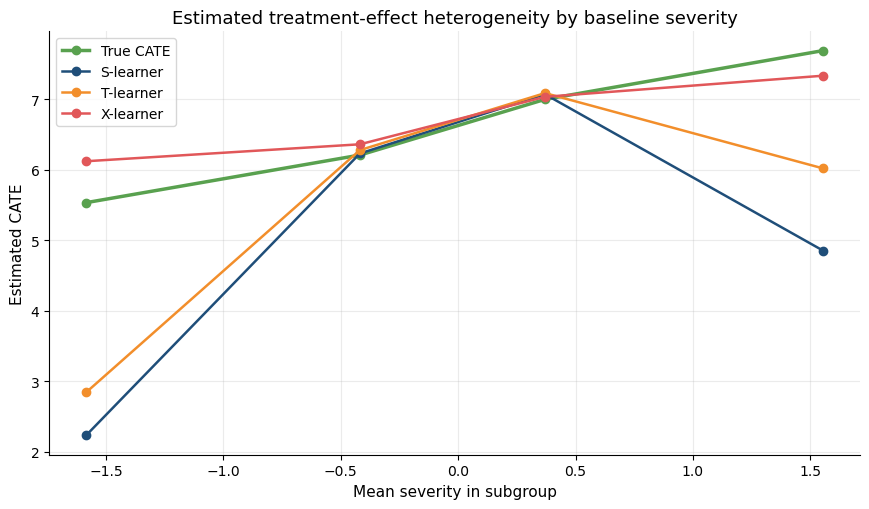

In [59]:
fig, ax = plt.subplots(figsize=(8.8, 5.2))

ax.plot(
    cate_by_severity["mean_severity"],
    cate_by_severity["true_cate"],
    marker="o",
    linewidth=2.5,
    label="True CATE",
    color=COLORS["green"]
)

ax.plot(
    cate_by_severity["mean_severity"],
    cate_by_severity["s_learner"],
    marker="o",
    linewidth=1.8,
    label="S-learner",
    color=COLORS["navy"]
)

ax.plot(
    cate_by_severity["mean_severity"],
    cate_by_severity["t_learner"],
    marker="o",
    linewidth=1.8,
    label="T-learner",
    color=COLORS["orange"]
)

ax.plot(
    cate_by_severity["mean_severity"],
    cate_by_severity["x_learner"],
    marker="o",
    linewidth=1.8,
    label="X-learner",
    color=COLORS["red"]
)

ax.set_title("Estimated treatment-effect heterogeneity by baseline severity")
ax.set_xlabel("Mean severity in subgroup")
ax.set_ylabel("Estimated CATE")
ax.legend()

clean_axis(ax)
plt.tight_layout()
plt.show()

### Interpretation

The plot compares the true CATE pattern with the estimates from the S-, T-, and X-learners.

The green curve shows the true simulated CATE.

It increases with baseline severity. This means higher-severity patients benefit more from treatment in this simulation.

The X-learner follows this increasing pattern most closely.

The S-learner and T-learner capture part of the pattern, especially in the middle severity groups. But they are less reliable at the extremes.

The key lesson is:

> Estimating CATE is harder than estimating ATE.

For decision-making, this matters. CATE estimates are often used to identify who may benefit most. They should therefore be interpreted with overlap checks, uncertainty analysis, and domain knowledge.

---
### 8.3 CATE, Decision Relevance, and Practical Cautions

<div style="color:#1f4e79; background-color:#eef5fb; border-left:4px solid #1f4e79; padding:10px 14px; margin:12px 0;">

<strong>Optional self-study.</strong><br>
If time is limited, we may skip this section in class. Please review it independently and run the code cells.

</div>

CATE estimates move the analysis from average effects to subgroup-level decision support.

The question is no longer only:

> Does the treatment improve recovery on average?

It becomes:

> Which patients are expected to benefit more or less?

In this simulation, treatment is beneficial across all four severity groups. But the expected benefit is larger for high-severity patients.

This means that `Severity` acts as an **effect modifier**.

A useful way to interpret CATE is:

| CATE pattern | Possible decision implication |
|---|---|
| Positive CATE for most groups | Treatment may be broadly useful |
| Larger CATE for high-severity patients | Treatment may be prioritized for severe cases |
| Near-zero CATE for some groups | Treatment benefit may be limited for those patients |
| Negative CATE for some groups | Treatment may be harmful or inappropriate for those patients |
| Strong disagreement across learners | More diagnostics and validation are needed |

The key lesson is:

> CATE estimation is not only about whether treatment works. It is about for whom treatment is expected to work more or less.


</br>

---
## 9. Double Machine Learning: Orthogonalization and Sample Splitting

Sections 7 and 8 introduced meta-learners.

Meta-learners estimate potential outcomes and compare predicted outcomes under treatment and no treatment.

**Double Machine Learning**, or **DML**, takes a different approach.

DML uses machine learning for two supporting prediction tasks:

1. predicting the outcome from pre-treatment covariates;
2. predicting treatment assignment from pre-treatment covariates.

These supporting models are called **nuisance models**.

They are not the final causal target. Their role is to remove variation explained by observed confounders.

In this section, the target is the average effect of `Treatment` on `RecoveryScore`.

We adjust for the same pre-treatment covariates used earlier:

- `Age`
- `Socioeconomic`
- `Severity`
- `Biomarker`

The main idea is:

> Remove from both the outcome and the treatment the parts predicted by pre-treatment covariates. Then estimate the treatment effect using what remains.

For a partially linear model, we write:

$$Y = \theta T + g(X) + \varepsilon$$

and:

$$T = e(X) + \eta$$

where:

- $Y$ is the outcome, `RecoveryScore`;
- $T$ is the treatment, `Treatment`;
- $X$ contains pre-treatment covariates;
- $\theta$ is the average treatment-effect parameter;
- $g(X) = E[Y \mid X]$ predicts the outcome from covariates;
- $e(X) = E[T \mid X]$ predicts treatment assignment from covariates.

DML estimates $g(X)$ and $e(X)$ using machine learning.

It then constructs residuals:

$$\tilde{Y} = Y - \hat{g}(X)$$

and:

$$\tilde{T} = T - \hat{e}(X)$$

The treatment effect is estimated from the residualized relationship:

$$
\hat{\theta}_{DML}
=
\frac{\sum_i \tilde{T}_i \tilde{Y}_i}
{\sum_i \tilde{T}_i^2}
$$

This is called **orthogonalization**.

It removes the parts of treatment and outcome that are explained by the covariates.

DML also uses **sample splitting**, or **cross-fitting**.

The nuisance models are trained on one part of the data and used to create residuals on another part. This helps reduce overfitting bias when flexible machine learning models are used.

- DML is not tied to one machine learning algorithm. In this chapter, we use random forests because they are flexible and suitable for nonlinear tabular data.

- Other models can also be used. A more complex ML model does not automatically make the causal estimate more credible. The practical rule is:

> Use machine learning to estimate the nuisance functions well, but keep the causal design fixed.


DML still requires:

- a valid treatment and outcome;
- a valid adjustment set;
- no major unmeasured confounding.


---
### 9.1 A Simple Implementation of Cross-Fitted DML

<div style="color:#1f4e79; background-color:#eef5fb; border-left:4px solid #1f4e79; padding:10px 14px; margin:12px 0;">

<strong>Optional self-study.</strong><br>
If time is limited, we may skip this section in class. Please review it independently and run the code cells.

</div>

The next code cell defines a simple teaching implementation of Double Machine Learning.

The function performs four steps:

1. split the data into folds;
2. train an outcome model $\hat{g}(X)$ and a treatment model $\hat{e}(X)$ on the training folds;
3. predict outcome and treatment assignment on the held-out fold;
4. compute residuals $\tilde{Y}$ and $\tilde{T}$ for the held-out fold.

After all folds are processed, the treatment effect is estimated by regressing the residualized outcome on the residualized treatment.

This implementation is intentionally simple so that the main idea of DML is visible. It estimates one average treatment effect, not heterogeneous treatment effects. Production applications usually use specialized packages such as `DoubleML` or `EconML`.

In [60]:
def cross_fitted_dml_ate(df, outcome, treatment, covariates, n_splits=5, seed=42):
    """Simple implementation of cross-fitted DML for a partially linear ATE.

    This function estimates one average treatment effect.
    It does not estimate heterogeneous treatment effects.
    """

    X = df[covariates].values
    Y = df[outcome].values
    T = df[treatment].values

    y_residual = np.zeros(len(df))
    t_residual = np.zeros(len(df))

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        Y_train = Y[train_idx]
        T_train = T[train_idx]

        # Outcome nuisance model: g(X) = E[Y | X]
        outcome_model = RandomForestRegressor(
            n_estimators=120,
            min_samples_leaf=20,
            random_state=seed
        )

        # Treatment nuisance model: e(X) = P(T = 1 | X)
        treatment_model = RandomForestClassifier(
            n_estimators=120,
            min_samples_leaf=20,
            random_state=seed
        )

        outcome_model.fit(X_train, Y_train)
        treatment_model.fit(X_train, T_train)

        # Predict on the held-out fold
        y_hat = outcome_model.predict(X_test)
        t_hat = treatment_model.predict_proba(X_test)[:, 1]

        # Residualize outcome and treatment
        y_residual[test_idx] = Y[test_idx] - y_hat
        t_residual[test_idx] = T[test_idx] - t_hat

    # Final residual-on-residual regression coefficient
    theta_hat = np.sum(t_residual * y_residual) / np.sum(t_residual ** 2)

    return theta_hat, y_residual, t_residual

### A note on the code cell

The function defines a simple cross-fitted DML estimator. It does not print a numerical result yet; it prepares the procedure that will be applied in the next cell.

The key feature is **cross-fitting**. For each fold, the outcome model $\hat{g}(X)$ and treatment model $\hat{e}(X)$ are trained on one part of the data and used to residualize another part. This helps reduce overfitting bias from flexible machine learning models.

The function returns three outputs:

- `theta_hat`: the DML estimate of the average treatment effect;
- `y_residual`: the part of `RecoveryScore` not explained by pre-treatment covariates;
- `t_residual`: the part of `Treatment` not explained by pre-treatment covariates.

The final estimate is obtained by relating the residualized outcome to the residualized treatment:

$$\hat{\theta}_{DML} =
\frac{\sum_i \tilde{T}_i \tilde{Y}_i}
{\sum_i \tilde{T}_i^2}
$$

The main lesson is:

> DML uses machine learning to remove predictable variation from both treatment and outcome, then estimates the causal effect from the remaining residual variation.

---
### 9.2 Estimate the DML Average Treatment Effect

The next code cell applies the cross-fitted DML function to the healthcare dataset.

We use only pre-treatment variables as covariates:

- `Age`
- `Socioeconomic`
- `Severity`
- `Biomarker`

This is important because the goal is to estimate the **total effect** of `Treatment` on `RecoveryScore`. The post-treatment mediator `Inflammation` is excluded because adjusting for it would block part of the treatment pathway and change the estimand.

In this implementation, DML estimates one average treatment effect. It does not estimate heterogeneous treatment effects.

In [61]:
# Important: use only pre-treatment variables as covariates for total-effect estimation.
dml_ate, y_resid, t_resid = cross_fitted_dml_ate(
    health,
    outcome="RecoveryScore",
    treatment="Treatment",
    covariates=adjustment_vars,
    n_splits=5,
    seed=42,
)

print(f"DML estimated ATE: {dml_ate:.3f}")
print(f"True ATE:          {true_ate:.3f}")

DML estimated ATE: 6.632
True ATE:          6.608


### Interpretation

The DML estimate is very close to the true ATE in this simulation.

The estimated effect is about 6.6 recovery-score points. This means that DML estimates that assigning treatment increases the average recovery score by about 6.6 points.

This is very different from the naive comparison, which suggested a negative effect. The reason is that DML adjusts for the pre-treatment covariates by modeling:

$$g(X) = E[Y \mid X]$$

and:

$$e(X) = E[T \mid X]$$

It then estimates the treatment effect using the residual variation that remains after removing the parts of both outcome and treatment that are predictable from $X$.

The key lesson is:

> DML can recover the average causal effect when the adjustment set is valid and the nuisance models are sufficiently accurate.

Because this is a simulation, we can compare the DML estimate with the true ATE. In real observational data, the true ATE is not available. We would need overlap checks, uncertainty estimates, sensitivity analysis, and domain knowledge to judge whether the estimate is credible.

---
### 9.3 Visualize Residualization

<div style="color:#1f4e79; background-color:#eef5fb; border-left:4px solid #1f4e79; padding:10px 14px; margin:12px 0;">

<strong>Optional self-study.</strong><br>
If time is limited, we may skip this section in class. Please review it independently and run the code cells.

</div>

The next code cell visualizes the core idea of DML residualization.

The left plot shows the raw relationship between `Treatment` and `RecoveryScore`. This view is confounded because treatment assignment depends on pre-treatment patient characteristics such as `Severity` and `Biomarker`.

The right plot shows the residualized relationship. Here, both treatment and recovery have been adjusted for the pre-treatment covariates:

$$\tilde{Y} = Y - \hat{g}(X)$$

and:

$$\tilde{T} = T - \hat{e}(X)$$

The red line shows the slope between residualized treatment and residualized outcome. This slope is the DML estimate of the average treatment effect.

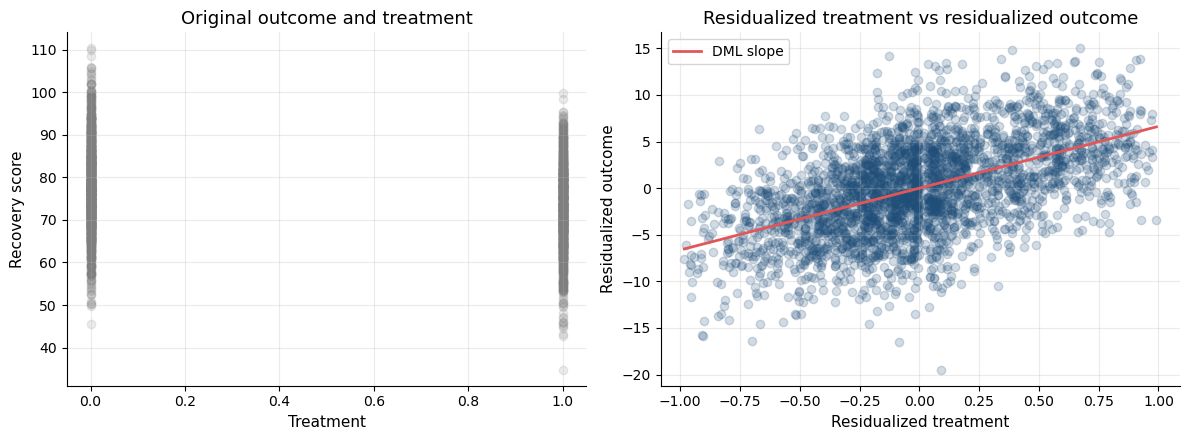

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Original treatment-outcome relationship
axes[0].scatter(
    health["Treatment"],
    health["RecoveryScore"],
    alpha=0.15,
    color=COLORS["gray"]
)
axes[0].set_title("Original outcome and treatment")
axes[0].set_xlabel("Treatment")
axes[0].set_ylabel("Recovery score")
clean_axis(axes[0])

# Residualized relationship
x_line = np.linspace(t_resid.min(), t_resid.max(), 100)
coef_line = dml_ate * x_line

axes[1].scatter(
    t_resid,
    y_resid,
    alpha=0.20,
    color=COLORS["navy"]
)
axes[1].plot(
    x_line,
    coef_line,
    color=COLORS["red"],
    linewidth=2,
    label="DML slope"
)
axes[1].set_title("Residualized treatment vs residualized outcome")
axes[1].set_xlabel("Residualized treatment")
axes[1].set_ylabel("Residualized outcome")
axes[1].legend()
clean_axis(axes[1])

plt.tight_layout()
plt.show()

### Interpretation

The two plots contrast the raw observational view with the DML residualized view.

In the left plot, `Treatment` is shown only as 0 or 1. This raw comparison is not causal because treated and untreated patients differ before treatment. In particular, treatment assignment depends on variables such as `Severity` and `Biomarker`.

The right plot shows what remains after residualization. The x-axis is the part of treatment assignment not predicted by the pre-treatment covariates:

$$\tilde{T} = T - \hat{e}(X)$$

The y-axis is the part of recovery score not predicted by the same covariates:

$$\tilde{Y} = Y - \hat{g}(X)$$

The red line shows the relationship between these two residuals. Its slope is the DML estimate of the average treatment effect.

The key lesson is:

> DML estimates the treatment effect after removing the covariate-predictable parts of both treatment and outcome.

This is why DML is useful when treatment assignment and outcomes depend on complex pre-treatment covariates.

---
### 9.4 Compare DML with Previous ATE Estimates

<div style="color:#1f4e79; background-color:#eef5fb; border-left:4px solid #1f4e79; padding:10px 14px; margin:12px 0;">

<strong>Optional self-study.</strong><br>
If time is limited, we may skip this section in class. Please review it independently and run the code cells.

</div>

The next code cell compares the DML estimate with the ATE estimates introduced earlier in the chapter.

This comparison helps place DML in the overall causal ML workflow. DML is not a replacement for causal design. It is another estimator that uses machine learning in a structured way: first to estimate nuisance functions, and then to estimate the treatment effect from residualized variation.

The table includes:

- the naive difference,
- the adjusted linear model,
- the S-, T-, and X-learners,
- DML,
- the true ATE from the simulation.

Because this is a simulation, the true ATE is available for evaluation. In real observational data, we would not know the true ATE and would need to rely on diagnostics, robustness checks, and domain knowledge.

In [63]:
dml_comparison = pd.DataFrame({
    "Method": [
        "Naive difference",
        "Adjusted linear model",
        "S-learner",
        "T-learner",
        "X-learner",
        "DML",
        "True ATE",
    ],
    "Estimated ATE": [
        naive_effect,
        lin_adjusted_effect,
        s_ate,
        t_ate,
        x_ate,
        dml_ate,
        true_ate,
    ]
})

dml_comparison["Absolute error vs true ATE"] = (
    dml_comparison["Estimated ATE"] - true_ate
).abs()

dml_comparison.round(3)

,Method,Estimated ATE,Absolute error vs true ATE
0,Naive difference,-4.999,11.606
1,Adjusted linear model,6.983,0.375
2,S-learner,5.097,1.510
3,T-learner,5.557,1.050
4,X-learner,6.713,0.105
5,DML,6.632,0.024
6,True ATE,6.608,0.000


### Interpretation

The table compares DML with the ATE estimators introduced earlier in the chapter.

- The naive difference is clearly misleading. It estimates a negative effect because it compares treated and untreated patients without adjusting for confounding.

- The adjusted linear model, S-learner, T-learner, X-learner, and DML all estimate positive effects. This means they agree on the main causal conclusion: treatment improves recovery on average.

- The estimates differ in magnitude. The S-learner and T-learner underestimate the true ATE in this run. The X-learner is close to the true ATE, while DML is closest in this simulation.

- DML performs well here because it uses machine learning to estimate the nuisance functions and then estimates the treatment effect from residualized variation.

The key lesson is:

> DML can provide a strong average treatment-effect estimate when the adjustment set is credible and the nuisance models capture the main outcome and treatment-assignment patterns.

This does not mean DML is always best. In real applications, we would compare estimators using diagnostics, uncertainty analysis, robustness checks, overlap assessment, and domain knowledge.

---
### 9.5 What DML Teaches Us

<div style="color:#1f4e79; background-color:#eef5fb; border-left:4px solid #1f4e79; padding:10px 14px; margin:12px 0;">

<strong>Optional self-study.</strong><br>
If time is limited, we may skip this section in class. Please review it independently and run the code cells.

</div>

DML provides three important lessons for causal machine learning.

| Concept | Meaning | Why it matters |
|---|---|---|
| Nuisance models | Estimate $g(X)=E[Y \mid X]$ and $e(X)=E[T \mid X]$ | ML is used for flexible prediction of outcome and treatment assignment |
| Orthogonalization | Remove from $Y$ and $T$ the parts explained by $X$ | Helps isolate treatment variation after accounting for observed confounders |
| Cross-fitting | Train nuisance models on one fold and residualize another fold | Reduces overfitting bias from flexible ML models |

DML is useful when the outcome process or treatment assignment process is nonlinear, complex, or high-dimensional. It separates the predictive tasks from the causal estimation task.

However, a more complex ML model does not automatically make the causal estimate more credible. DML still requires:

- a clearly defined treatment and outcome,
- a valid pre-treatment adjustment set,
- no important unmeasured confounders,
- sufficient overlap between treated and untreated patients,
- careful interpretation of the estimand.


</br>

---
## 10. Practical Guidance for Causal ML Implementation

This chapter introduced several estimators: naive comparison, adjusted outcome modeling, meta-learners, and Double Machine Learning. These methods differ in complexity, but they all depend on the same causal foundation.

The purpose of method comparison is not to choose the most advanced method. It is to understand whether the causal conclusion is stable across reasonable modeling choices.

| Method | Main target | Useful when | Main caution |
|---|---|---|---|
| Naive difference | Observed association | As a diagnostic starting point | Confounded when treatment is not random |
| Adjusted outcome model | ATE | Adjustment set is clear and relationships are simple | Sensitive to model misspecification |
| S-learner | ATE and CATE | A simple ML-based baseline is needed | May smooth or shrink treatment effects |
| T-learner | ATE and CATE | Treated and untreated groups both have enough data | Sensitive to weak overlap |
| X-learner | ATE and CATE | Treatment effects are heterogeneous and groups are imbalanced | More complex; depends on several fitted models |
| DML | ATE | Nuisance relationships are nonlinear or complex | Requires valid adjustment, overlap, and good nuisance models |

In real projects, disagreement across methods should be interpreted carefully. It may indicate weak overlap, model sensitivity, heterogeneous effects, or possible missing confounding. Agreement across methods does not prove causality, but it can increase confidence when the causal design is credible.

A practical checklist is:

| Step | Key question |
|---|---|
| Causal question | What treatment, intervention, or policy is being evaluated? |
| Outcome | What response do we want to change? |
| Estimand | Are we estimating ATE, ATT, ATU, CATE, or another quantity? |
| Adjustment set | Which variables are measured before treatment and needed for adjustment? |
| Exclusions | Are there mediators, colliders, or post-treatment variables that should not be adjusted for? |
| Overlap | Are treated and untreated units comparable across the covariate space? |
| Method choice | Is a simple adjusted model enough, or is flexible causal ML needed? |
| Validation | Are results stable across methods, subgroups, and modeling choices? |
| Interpretation | Are results presented as causal estimates under assumptions, not as proof? |

The practical rule is:

> Start with the causal design, then choose the machine learning method.


</br>

---
## 11. Chapter Summary

This chapter introduced causal machine learning for estimating average and heterogeneous treatment effects.

The main message is:

> Machine learning can improve causal effect estimation, but only when it is embedded in a credible causal design.

Key points from the chapter:

- Ordinary machine learning predicts observed outcomes such as $E[Y \mid X]$ or $E[Y \mid T, X]$.
- Causal effect estimation targets interventional and counterfactual quantities such as $E[Y \mid do(T=1)] - E[Y \mid do(T=0)]$.
- The fundamental problem of causal inference is that each unit has a missing counterfactual outcome.
- ATE, ATT, ATU, and CATE answer different causal questions.
- Naive treated-versus-untreated comparisons can be severely biased when treatment assignment is confounded.
- Adjusted outcome modeling improves estimation by comparing treatment conditions over the same covariate distribution.
- S-, T-, and X-learners use supervised learning models to estimate average and heterogeneous treatment effects.
- CATE analysis helps answer not only whether treatment works, but for whom it is expected to work more or less.
- Double Machine Learning uses nuisance models, residualization, orthogonalization, and cross-fitting to estimate average causal effects with flexible ML.
- Method comparison helps reveal whether conclusions are stable or sensitive to modeling choices.

The central lesson is:

> Causal machine learning is not a single algorithm. It is a workflow: define the causal question, choose the estimand, specify the adjustment strategy, select an estimator, validate the result, and interpret the estimate under explicit assumptions.

</br>

---
## 12. References and Further Reading

### Foundational causal inference

- Neal, B. (2020). [Introduction to Causal Inference from a Machine Learning Perspective](https://www.bradyneal.com/causal-inference-course). Course notes.  
  A machine-learning-oriented introduction to causal inference, useful for students with a computer science or data science background.

### Heterogeneous treatment effects and meta-learners

- Künzel, S. R., Sekhon, J. S., Bickel, P. J., and Yu, B. (2019). [Metalearners for estimating heterogeneous treatment effects using machine learning](https://www.pnas.org/doi/10.1073/pnas.1804597116). *Proceedings of the National Academy of Sciences*.  
  The main reference for S-, T-, and X-learners and their use in estimating conditional average treatment effects.

- Athey, S., and Imbens, G. (2016). [Recursive partitioning for heterogeneous causal effects](https://www.pnas.org/doi/10.1073/pnas.1510489113). *Proceedings of the National Academy of Sciences*.  
  An important early reference on tree-based methods for discovering treatment-effect heterogeneity.

- Wager, S., and Athey, S. (2018). [Estimation and inference of heterogeneous treatment effects using random forests](https://doi.org/10.1080/01621459.2017.1319839). *Journal of the American Statistical Association*.  
  A key reference for causal forests and inference for heterogeneous treatment effects.

### Double Machine Learning

- Chernozhukov, V., Chetverikov, D., Demirer, M., Duflo, E., Hansen, C., Newey, W., and Robins, J. (2018). [Double/debiased machine learning for treatment and structural parameters](https://academic.oup.com/ectj/article/21/1/C1/5056401). *The Econometrics Journal*.  
  The core reference for Double/Debiased Machine Learning, orthogonalization, nuisance functions, and sample splitting.

- Bach, P., Chernozhukov, V., Kurz, M. S., and Spindler, M. (2022). [DoubleML: An object-oriented implementation of Double Machine Learning in Python](https://www.jmlr.org/papers/v23/21-0862.html). *Journal of Machine Learning Research*.  
  A practical reference for implementing Double Machine Learning in Python.

### Python tools and documentation

- Battocchi, K., Dillon, E., Hei, M., Lewis, G., Oka, P., Oprescu, M., and Syrgkanis, V. (2019). [EconML: A Python package for ML-based heterogeneous treatment effects estimation](https://github.com/py-why/EconML). Software package and documentation.  
  A practical Python package for estimating heterogeneous treatment effects using methods such as DML, causal forests, and meta-learners.

- Microsoft Research. [EconML project page](https://www.microsoft.com/en-us/research/project/econml/).  
  Additional documentation and examples for applying machine learning to individualized causal response estimation.